In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules
from lfp_spike_window_analysis import *
from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [3]:
cell_num =27 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 27  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 27

## Step 0: Get loaded data 

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c27_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c27patch_filt.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

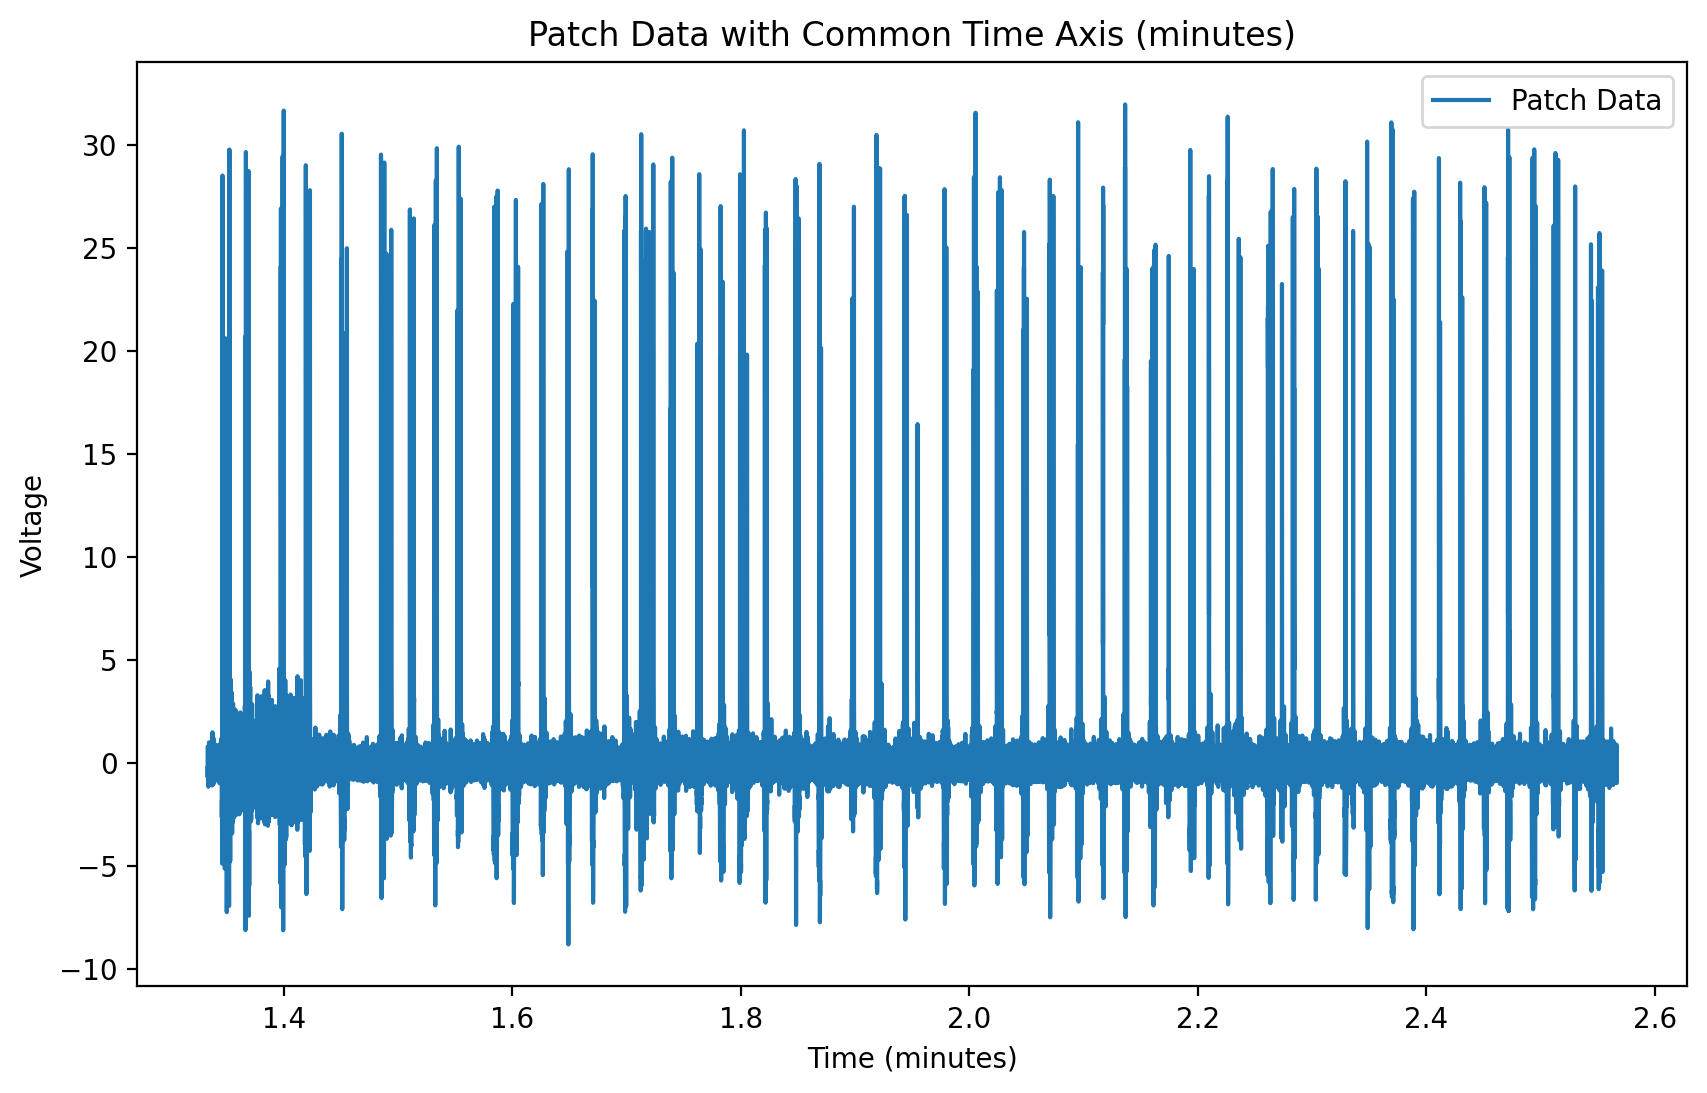

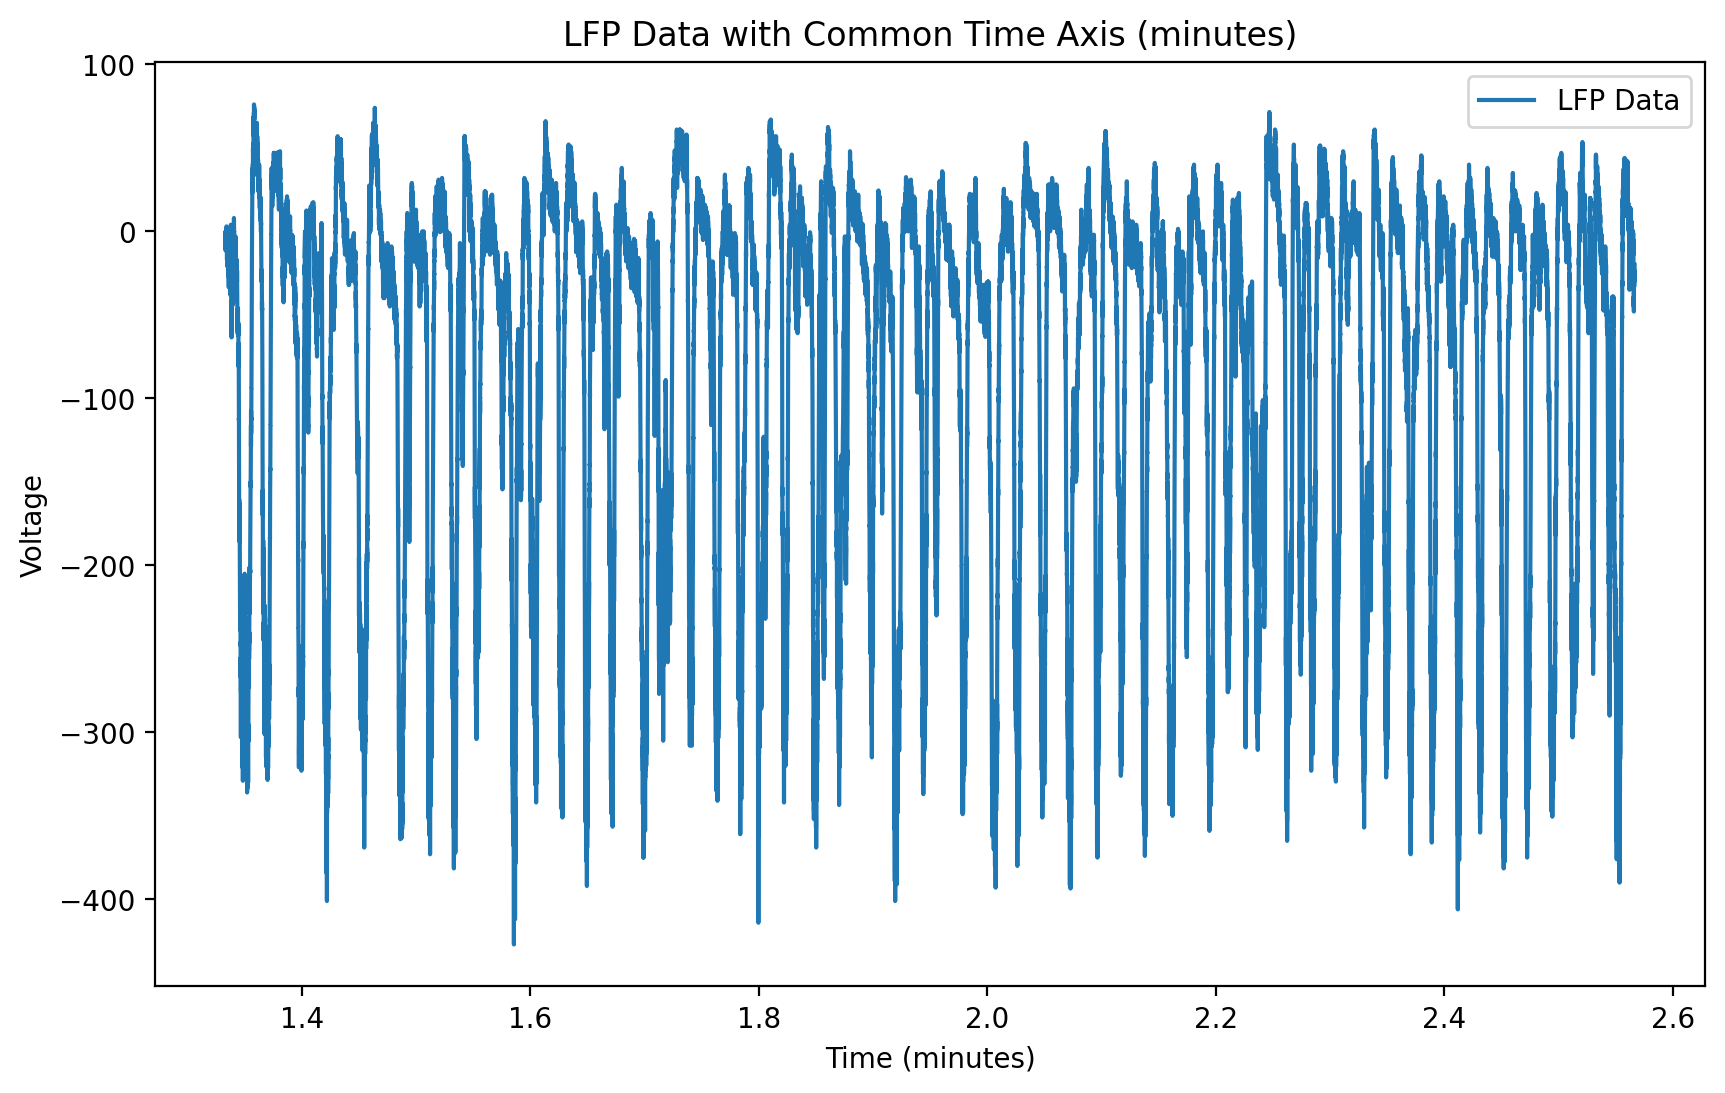

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

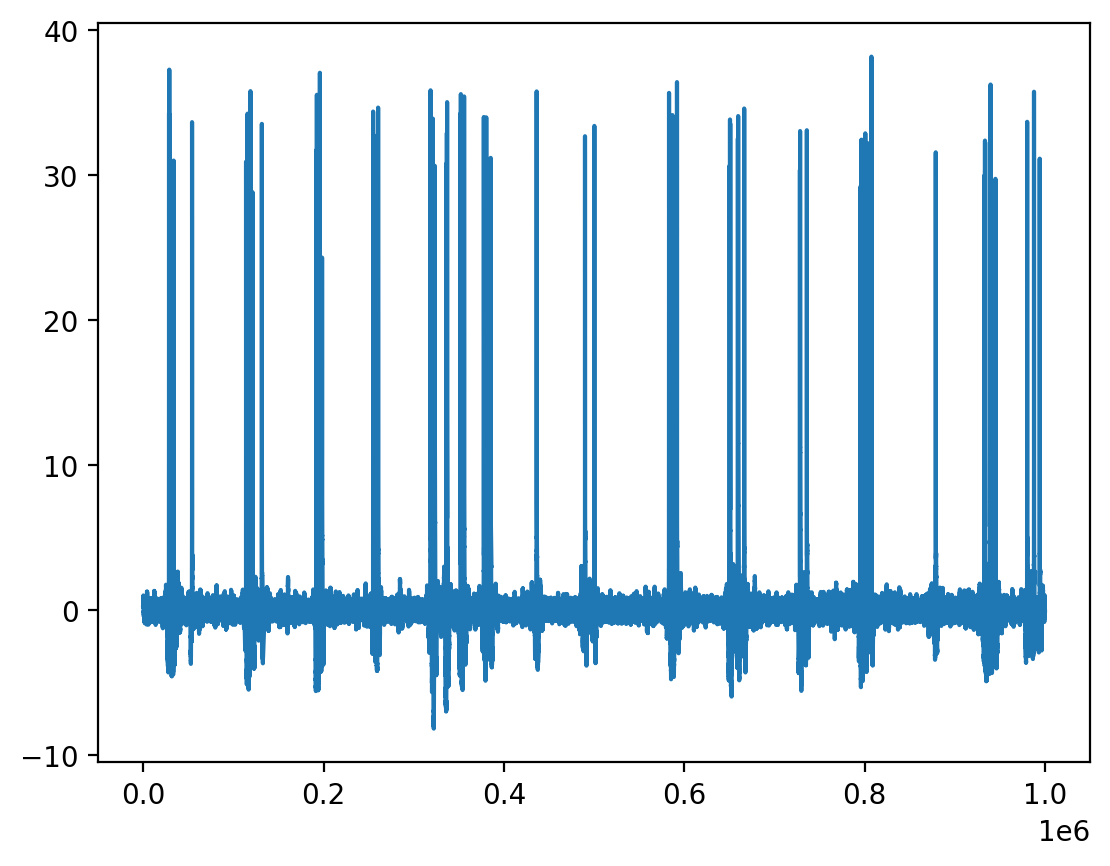

In [7]:
plt.plot(patch_filt[:1000000] )

In [8]:



#threshold in mVs
sp = Spike(thresh_amp=15, window_length=(5., 5.), smooth_frac=.01)

In [9]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=False)

Spike:   0%|          | 0/1496 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


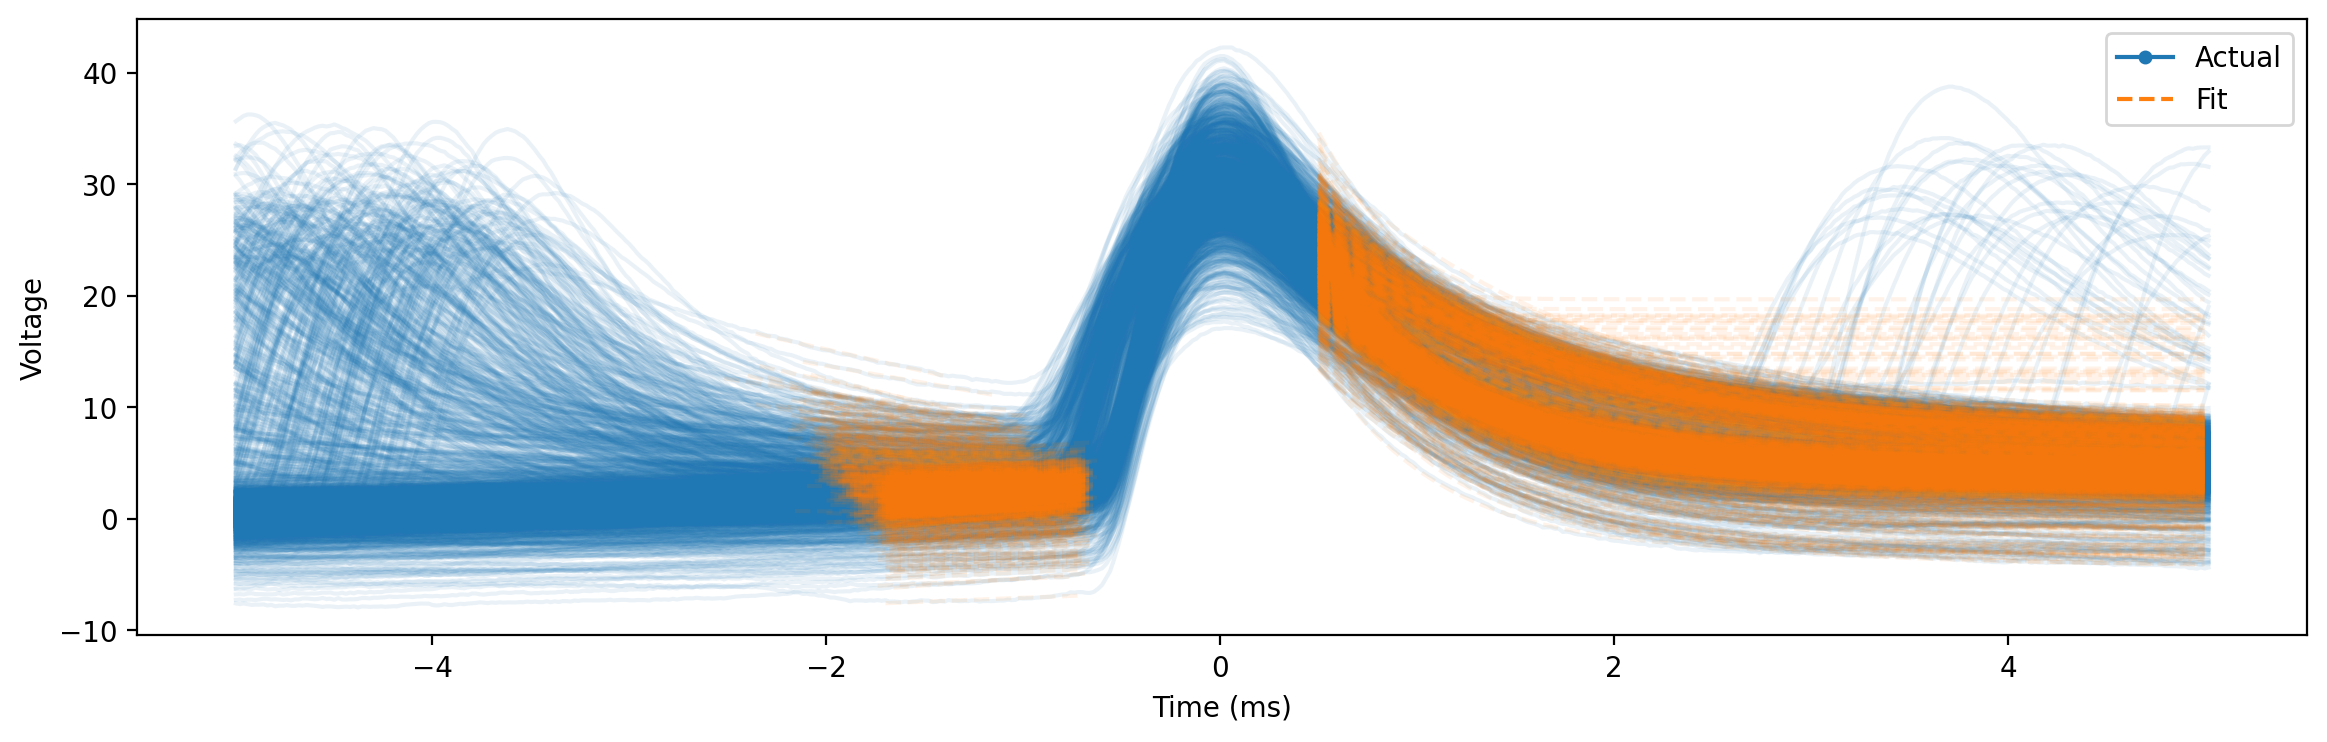

In [10]:
sp.plot()

### Filter spikes 

In [11]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [12]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [13]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,0.831264,0.76,2.175625,37.159431,1.54,0.488185,1.060599,6.280598,1.822091,28974,579.203281,0
1,1.301123,0.68,2.432262,26.044590,1.28,0.565906,0.785925,1.198710,1.469320,32295,645.591564,1
3,1.208969,0.66,1.659889,33.597074,1.08,0.883541,1.675188,2.721035,3.078032,54213,1083.742234,2
4,0.901014,0.66,-1.549076,30.813059,1.12,0.899997,1.446296,-0.961640,1.517516,114083,2280.570440,3
6,0.848046,0.66,3.066991,35.618422,1.08,0.978739,1.788263,4.431164,1.679039,118955,2377.963910,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1491,1.045474,0.66,4.731849,38.264729,1.08,0.899013,1.643298,6.161639,1.922207,40394322,807500.650423,1405
1492,0.867023,0.72,3.797083,32.244505,1.14,0.731312,1.293713,3.493535,3.164163,40398504,807584.250482,1406
1493,0.927436,0.74,3.426125,25.883916,1.48,0.471966,0.963138,5.629404,1.815370,40471507,809043.613260,1407
1494,0.579992,0.64,4.471907,36.945890,1.06,0.991244,1.668280,4.414232,1.683380,40474777,809108.982030,1408


### Get spike times


In [14]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 2: Cluster ISI spike groups 

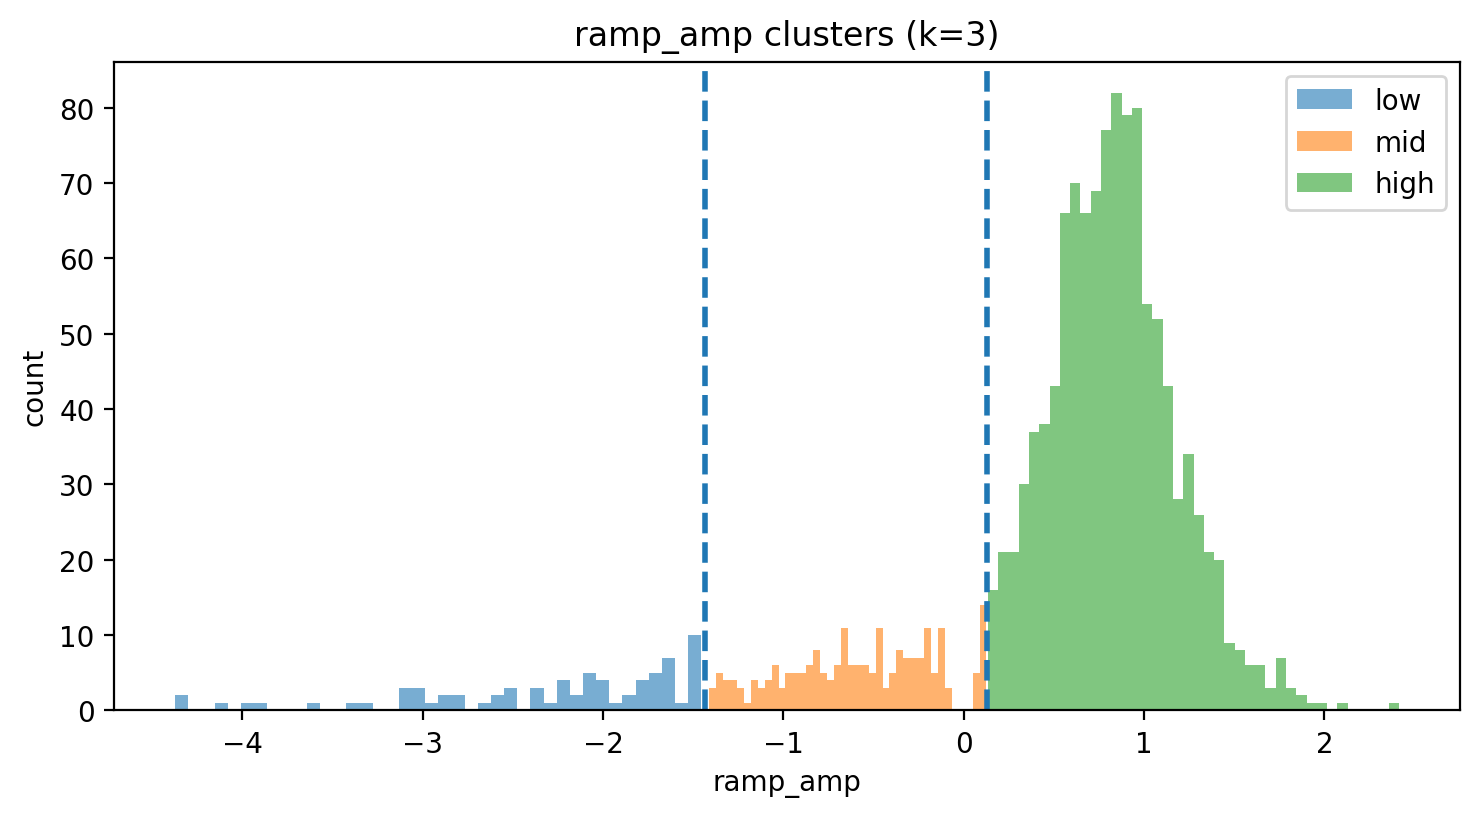

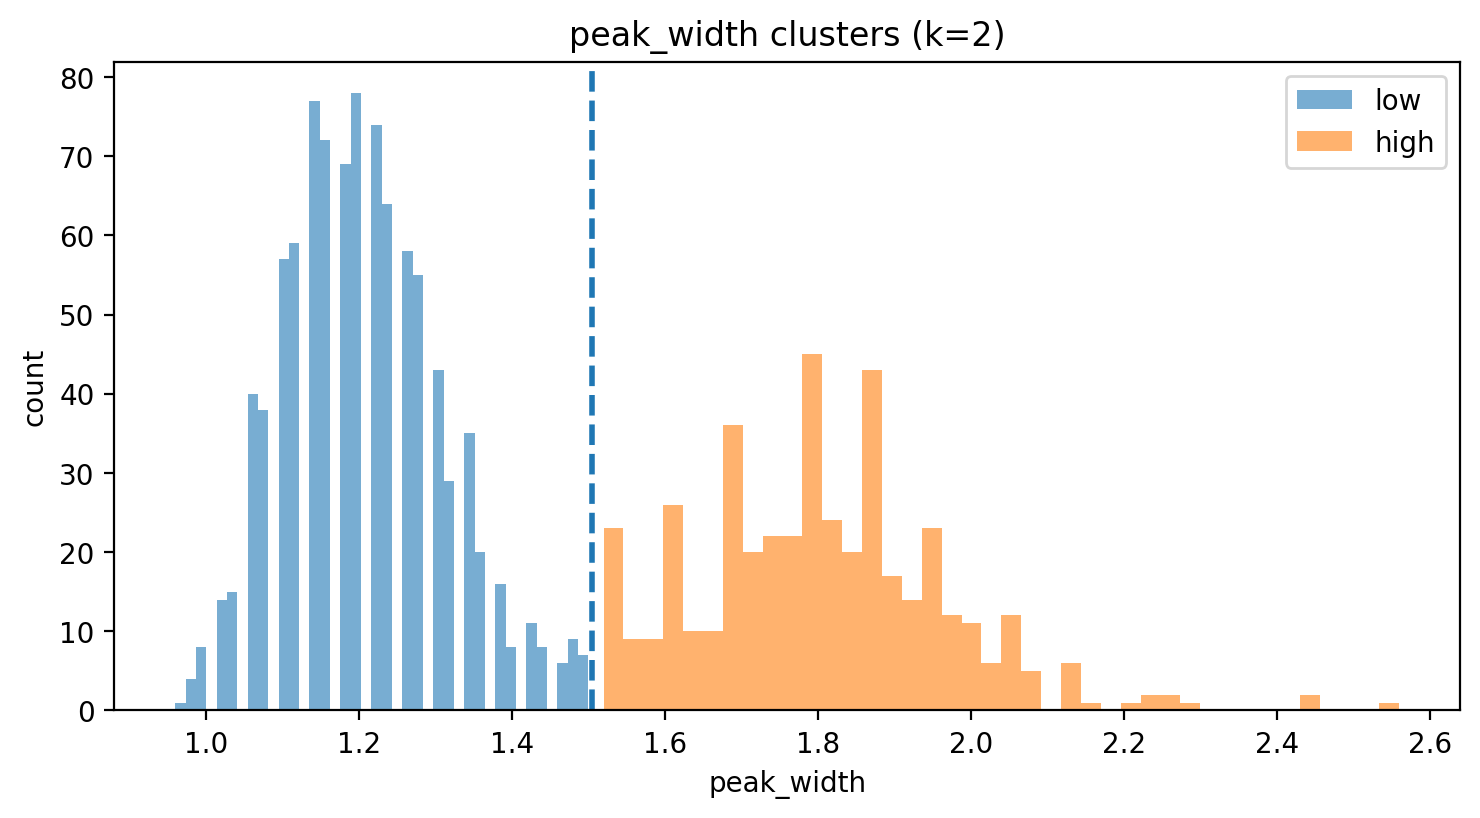

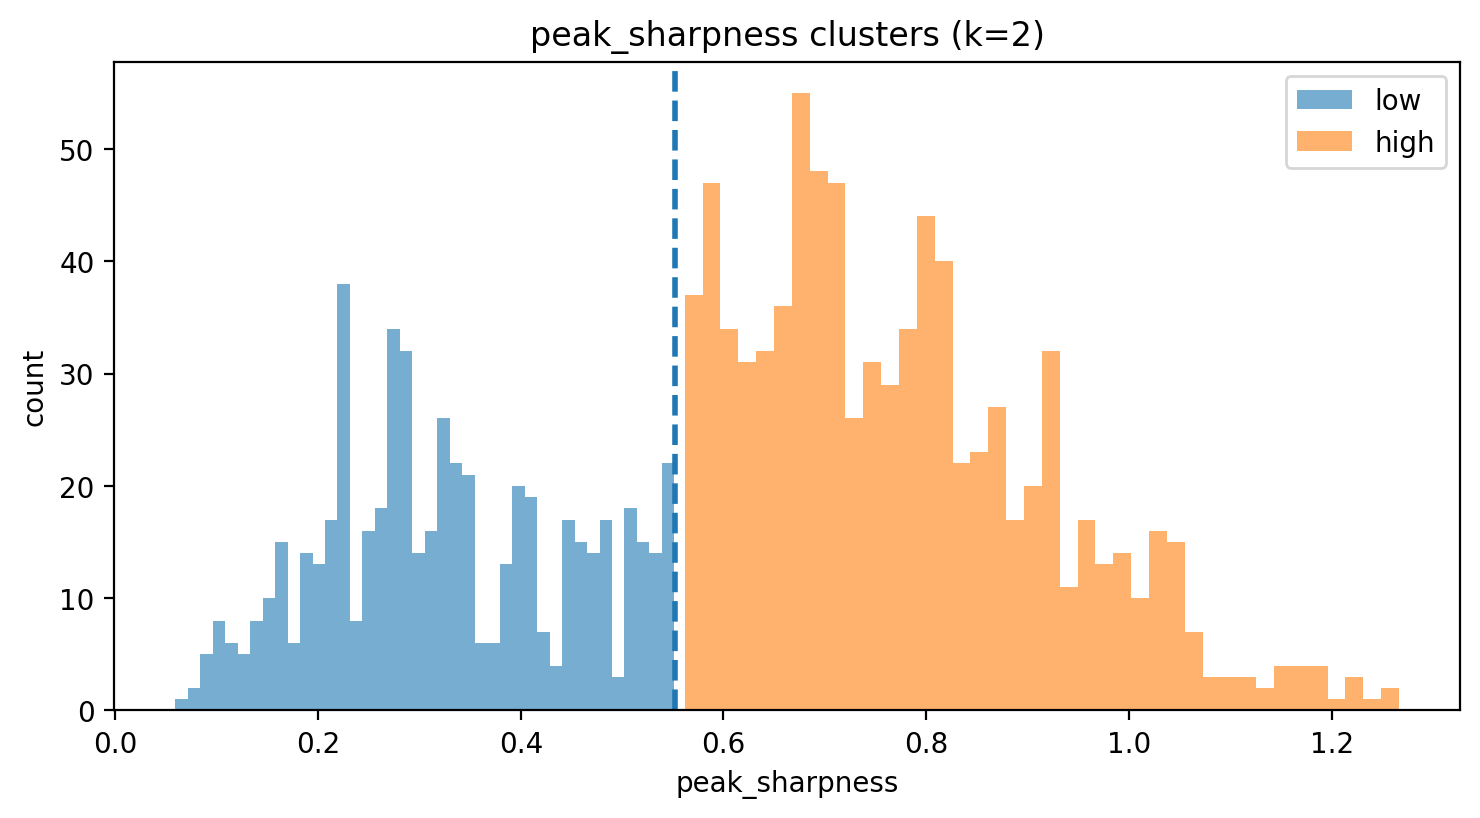

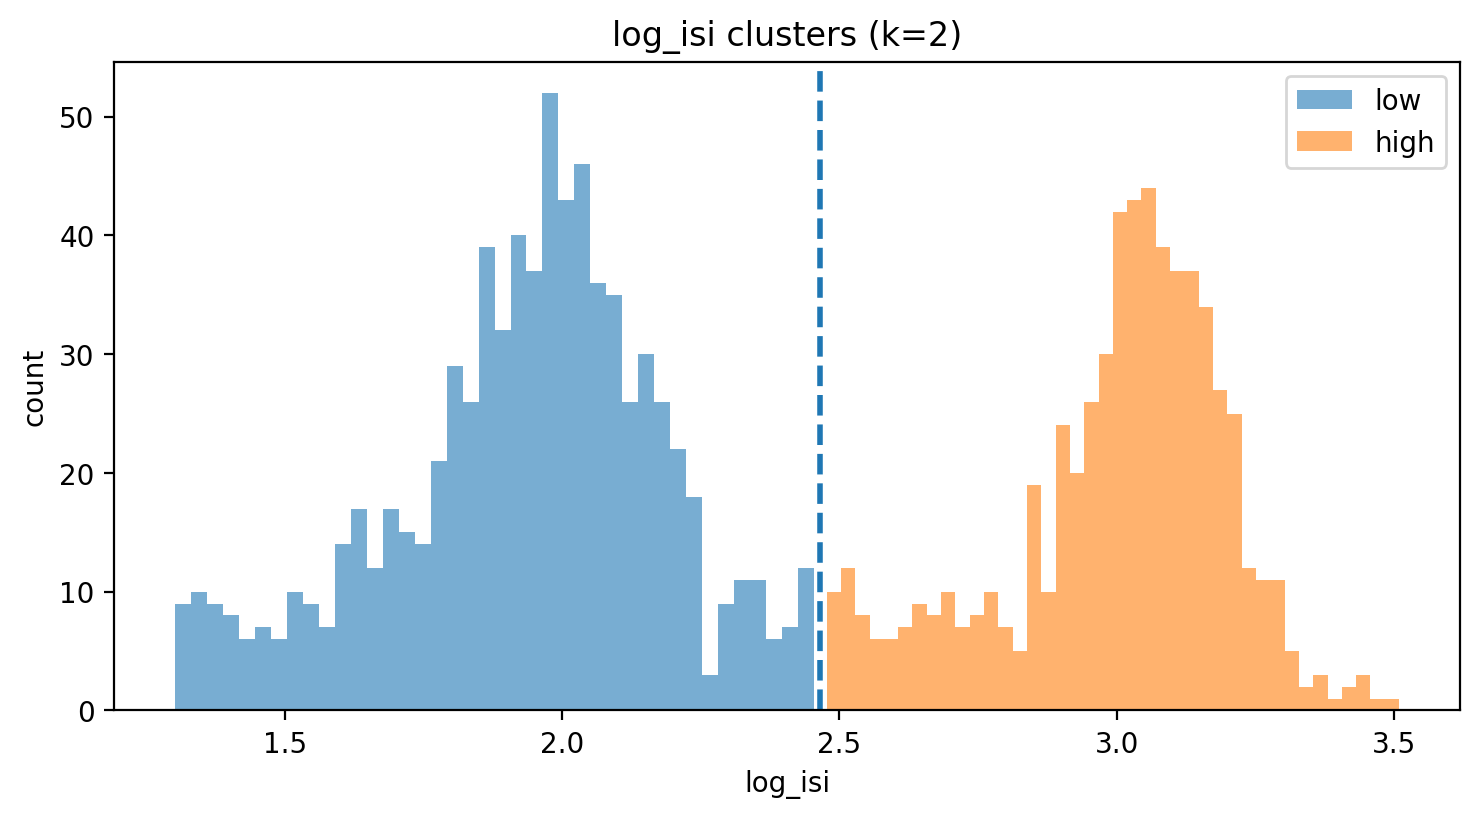

In [15]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features,
    max_k=3,
    suffix="_cluster",
    plot_each=True  # set True if you want a quick plot per clustered feature
)







In [16]:
df_features_clust

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id,ramp_amp_cluster,peak_width_cluster,peak_sharpness_cluster,log_isi_cluster
0,0.831264,0.76,2.175625,37.159431,1.54,0.488185,1.060599,6.280598,1.822091,28974,579.203281,0,high,high,low,low
1,1.301123,0.68,2.432262,26.044590,1.28,0.565906,0.785925,1.198710,1.469320,32295,645.591564,1,high,low,high,low
3,1.208969,0.66,1.659889,33.597074,1.08,0.883541,1.675188,2.721035,3.078032,54213,1083.742234,2,high,low,high,high
4,0.901014,0.66,-1.549076,30.813059,1.12,0.899997,1.446296,-0.961640,1.517516,114083,2280.570440,3,high,low,high,low
6,0.848046,0.66,3.066991,35.618422,1.08,0.978739,1.788263,4.431164,1.679039,118955,2377.963910,4,high,low,high,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1491,1.045474,0.66,4.731849,38.264729,1.08,0.899013,1.643298,6.161639,1.922207,40394322,807500.650423,1405,high,low,high,low
1492,0.867023,0.72,3.797083,32.244505,1.14,0.731312,1.293713,3.493535,3.164163,40398504,807584.250482,1406,high,low,high,high
1493,0.927436,0.74,3.426125,25.883916,1.48,0.471966,0.963138,5.629404,1.815370,40471507,809043.613260,1407,high,low,low,low
1494,0.579992,0.64,4.471907,36.945890,1.06,0.991244,1.668280,4.414232,1.683380,40474777,809108.982030,1408,high,low,high,low


### STETP 3: Separate spikes into short ISIs and long ISIs and find transition points (long ISI spikes to group of short ISI spikes)

#### Visualize ISI spike cluster groups over time 

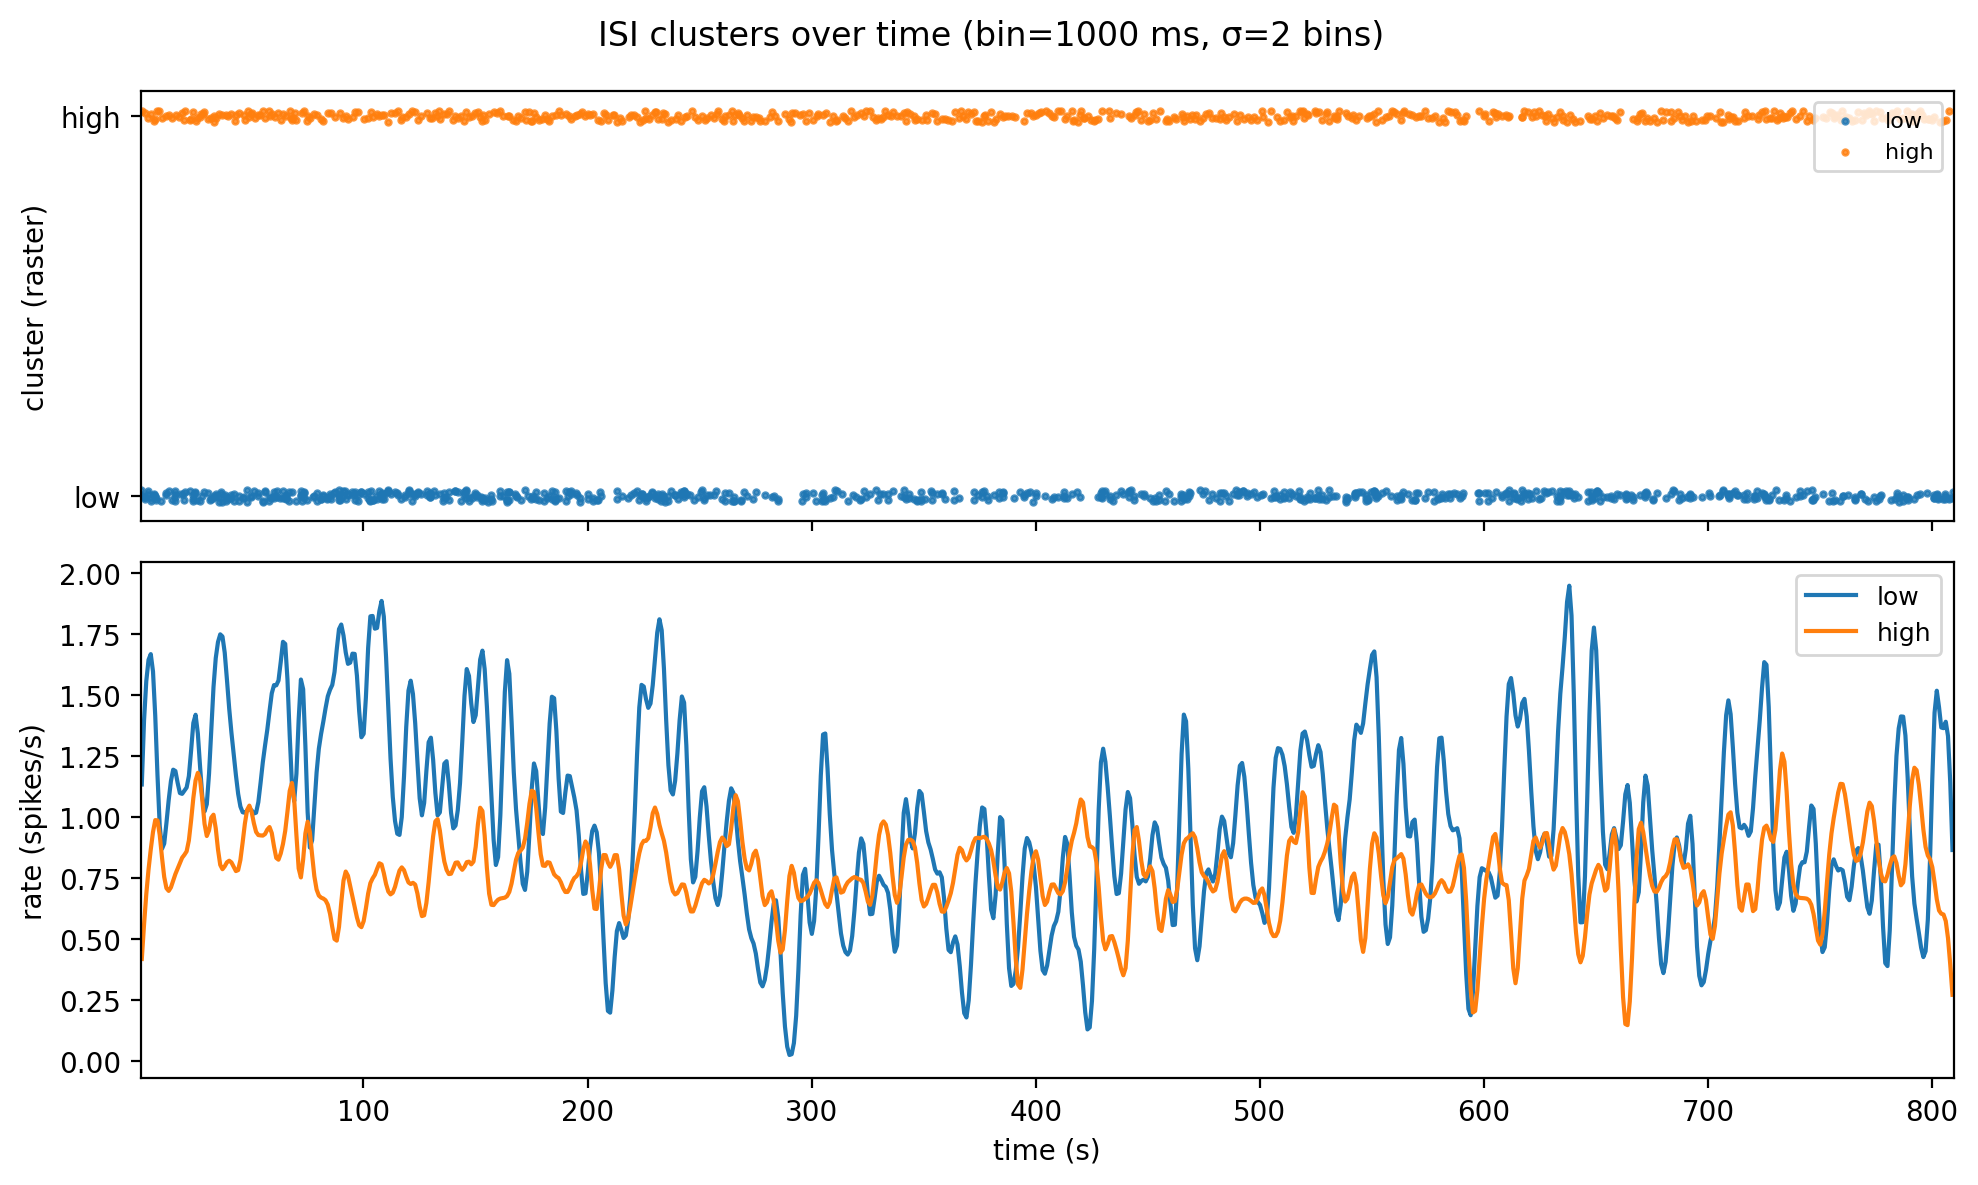

In [17]:
plot_clusters_over_time_min(
    df_features_clust,
    time_col="spk_times_ms",
    label_col="log_isi_cluster",   # your labels are 'low'/'high'
    time_unit="ms",
    bin_size_ms=1000,
    sigma_bins=2
)


#### Calculate transition probabilities 

          high       low
high  0.279743  0.720257
low   0.569975  0.430025


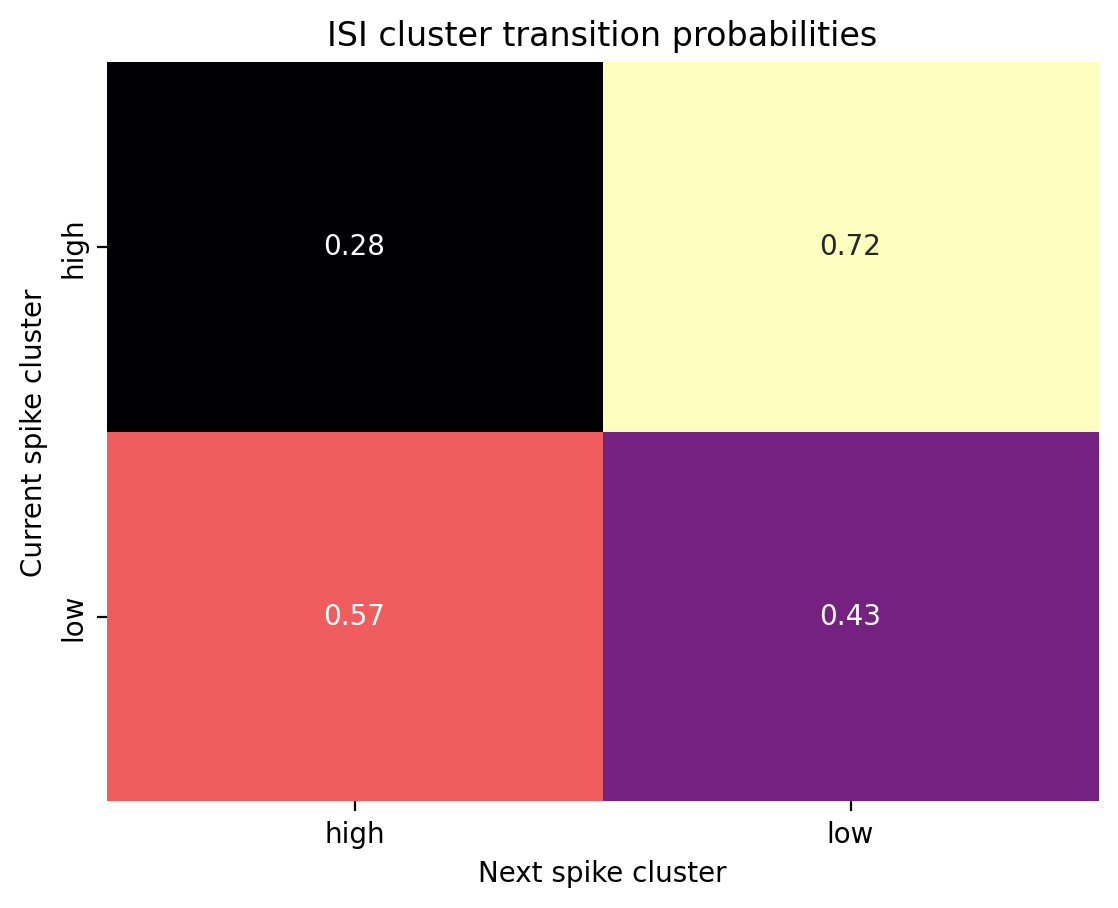

In [18]:
trans_mat = isi_transition_matrix(df_features_clust, "log_isi_cluster")
print(trans_mat)

sns.heatmap(trans_mat, annot=True, cmap="magma", cbar=False)
plt.title("ISI cluster transition probabilities")
plt.xlabel("Next spike cluster")
plt.ylabel("Current spike cluster")
plt.show()


#### Find transition points 

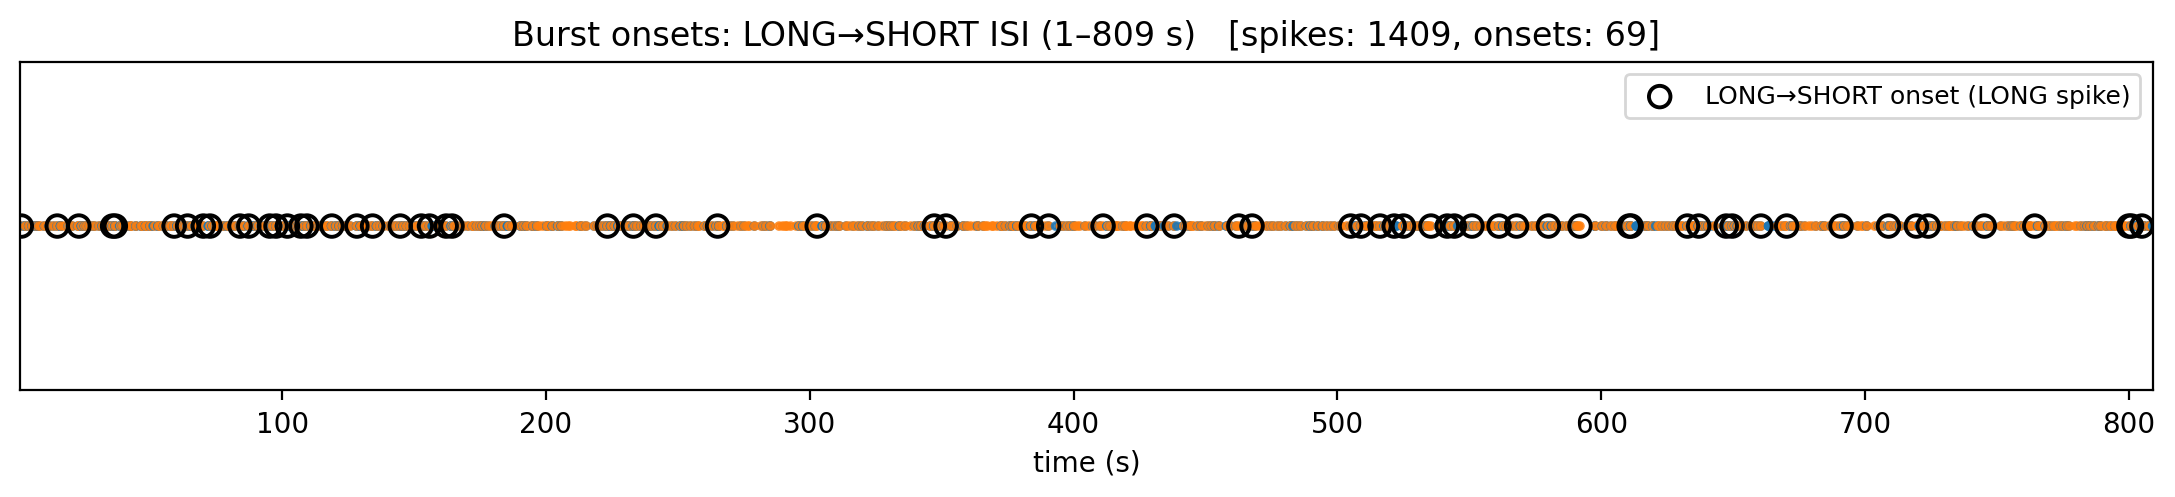

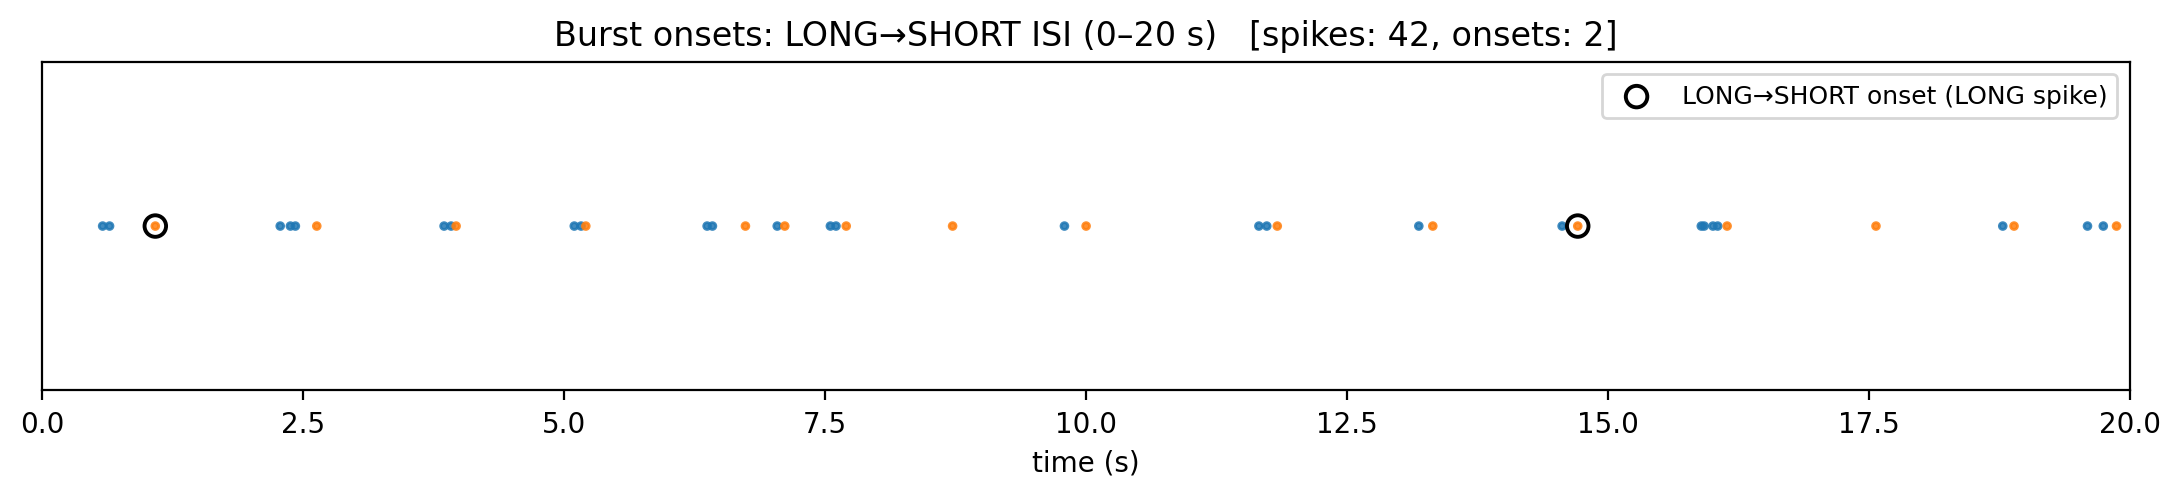

In [19]:
# Identify high spikes that start low bursts
df_marked = mark_high_burst_onsets(
    df_features_clust,
    cluster_col="log_isi_cluster",
    time_col="spk_times_ms",
    min_low_run=3  # how many LOW spikes must follow to count as a burst
)

# Plot full timeline
plot_long_to_short_isi_onsets(
    df_marked,
    time_col="spk_times_ms",
    cluster_col="log_isi_cluster"          

)


# Zoom into a specific range 
plot_long_to_short_isi_onsets(
    df_marked,
    time_col="spk_times_ms",
    cluster_col="log_isi_cluster",
    time_range=(00, 20)  # seconds
)


In [20]:
df_marked

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id,ramp_amp_cluster,peak_width_cluster,peak_sharpness_cluster,log_isi_cluster,is_long_to_short_isi_onset
0,0.831264,0.76,2.175625,37.159431,1.54,0.488185,1.060599,6.280598,1.822091,28974,579.203281,0,high,high,low,low,False
1,1.301123,0.68,2.432262,26.044590,1.28,0.565906,0.785925,1.198710,1.469320,32295,645.591564,1,high,low,high,low,False
2,1.208969,0.66,1.659889,33.597074,1.08,0.883541,1.675188,2.721035,3.078032,54213,1083.742234,2,high,low,high,high,True
3,0.901014,0.66,-1.549076,30.813059,1.12,0.899997,1.446296,-0.961640,1.517516,114083,2280.570440,3,high,low,high,low,False
4,0.848046,0.66,3.066991,35.618422,1.08,0.978739,1.788263,4.431164,1.679039,118955,2377.963910,4,high,low,high,low,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,1.045474,0.66,4.731849,38.264729,1.08,0.899013,1.643298,6.161639,1.922207,40394322,807500.650423,1405,high,low,high,low,False
1406,0.867023,0.72,3.797083,32.244505,1.14,0.731312,1.293713,3.493535,3.164163,40398504,807584.250482,1406,high,low,high,high,False
1407,0.927436,0.74,3.426125,25.883916,1.48,0.471966,0.963138,5.629404,1.815370,40471507,809043.613260,1407,high,low,low,low,False
1408,0.579992,0.64,4.471907,36.945890,1.06,0.991244,1.668280,4.414232,1.683380,40474777,809108.982030,1408,high,low,high,low,False


#### Look at the other waveform features for the "transition" spikes
There are no significant differences in the waveform features forr the transition spikes vs other spikes

ramp_amp            : t-test        (p=0.6)  | normal_a=True, normal_b=True, equal_var=True → normal or large n → t-test used
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


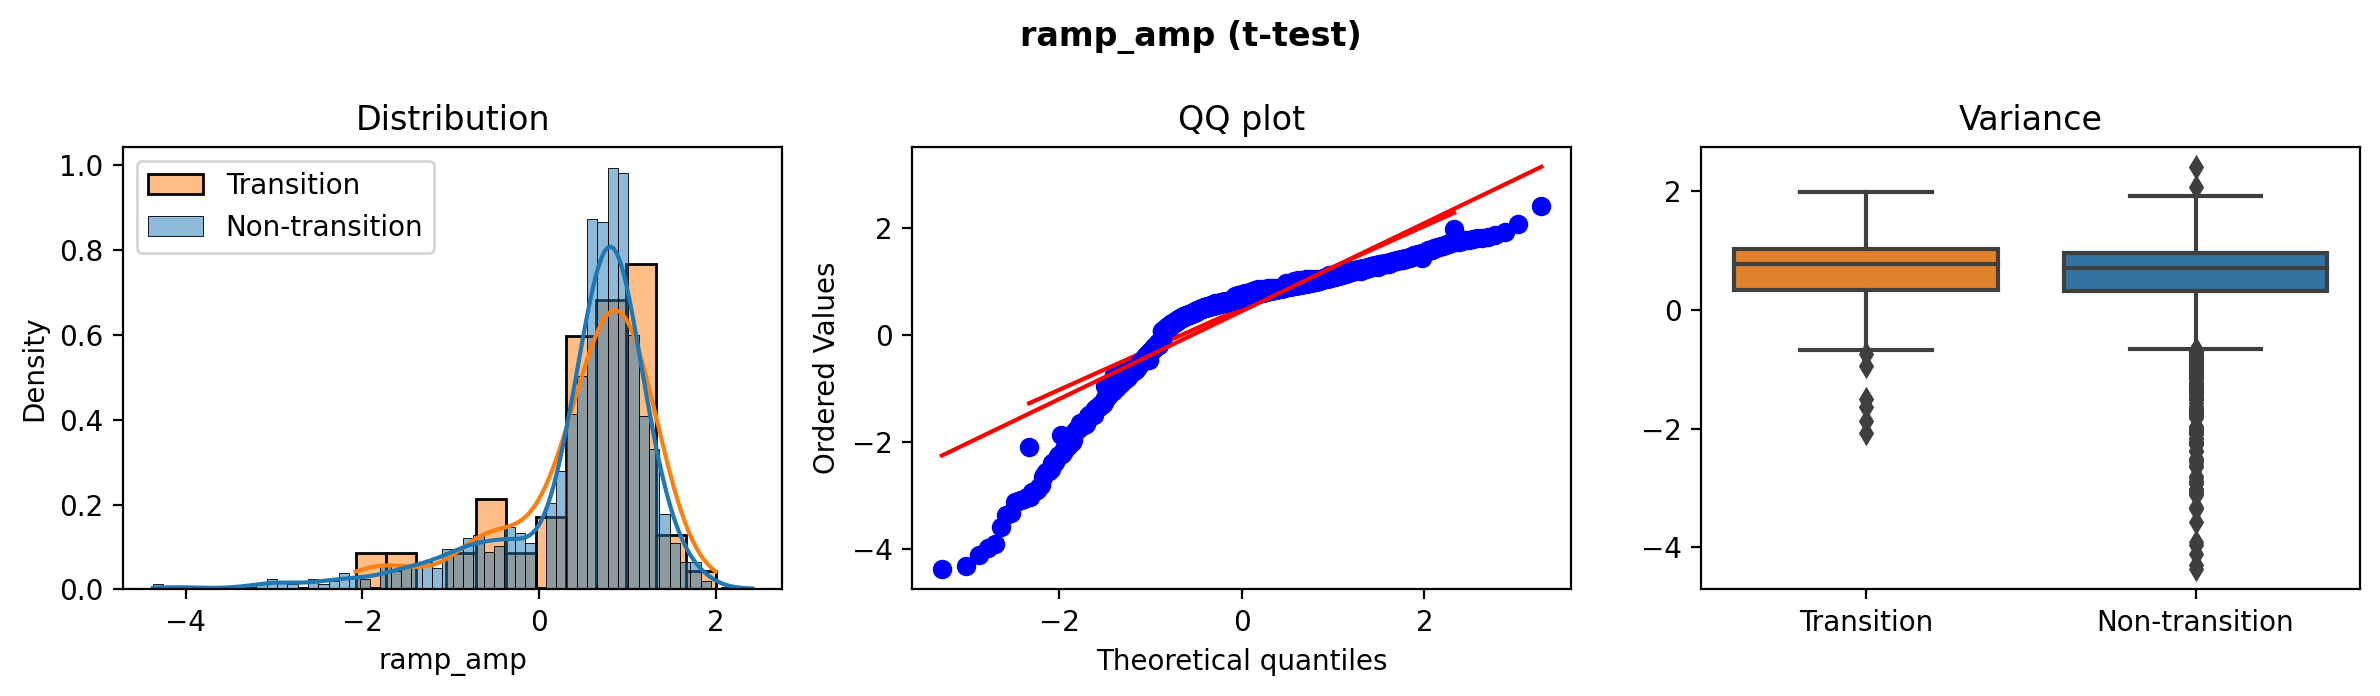

peak_width          : t-test        (p=0.89)  | normal_a=True, normal_b=True, equal_var=True → normal or large n → t-test used


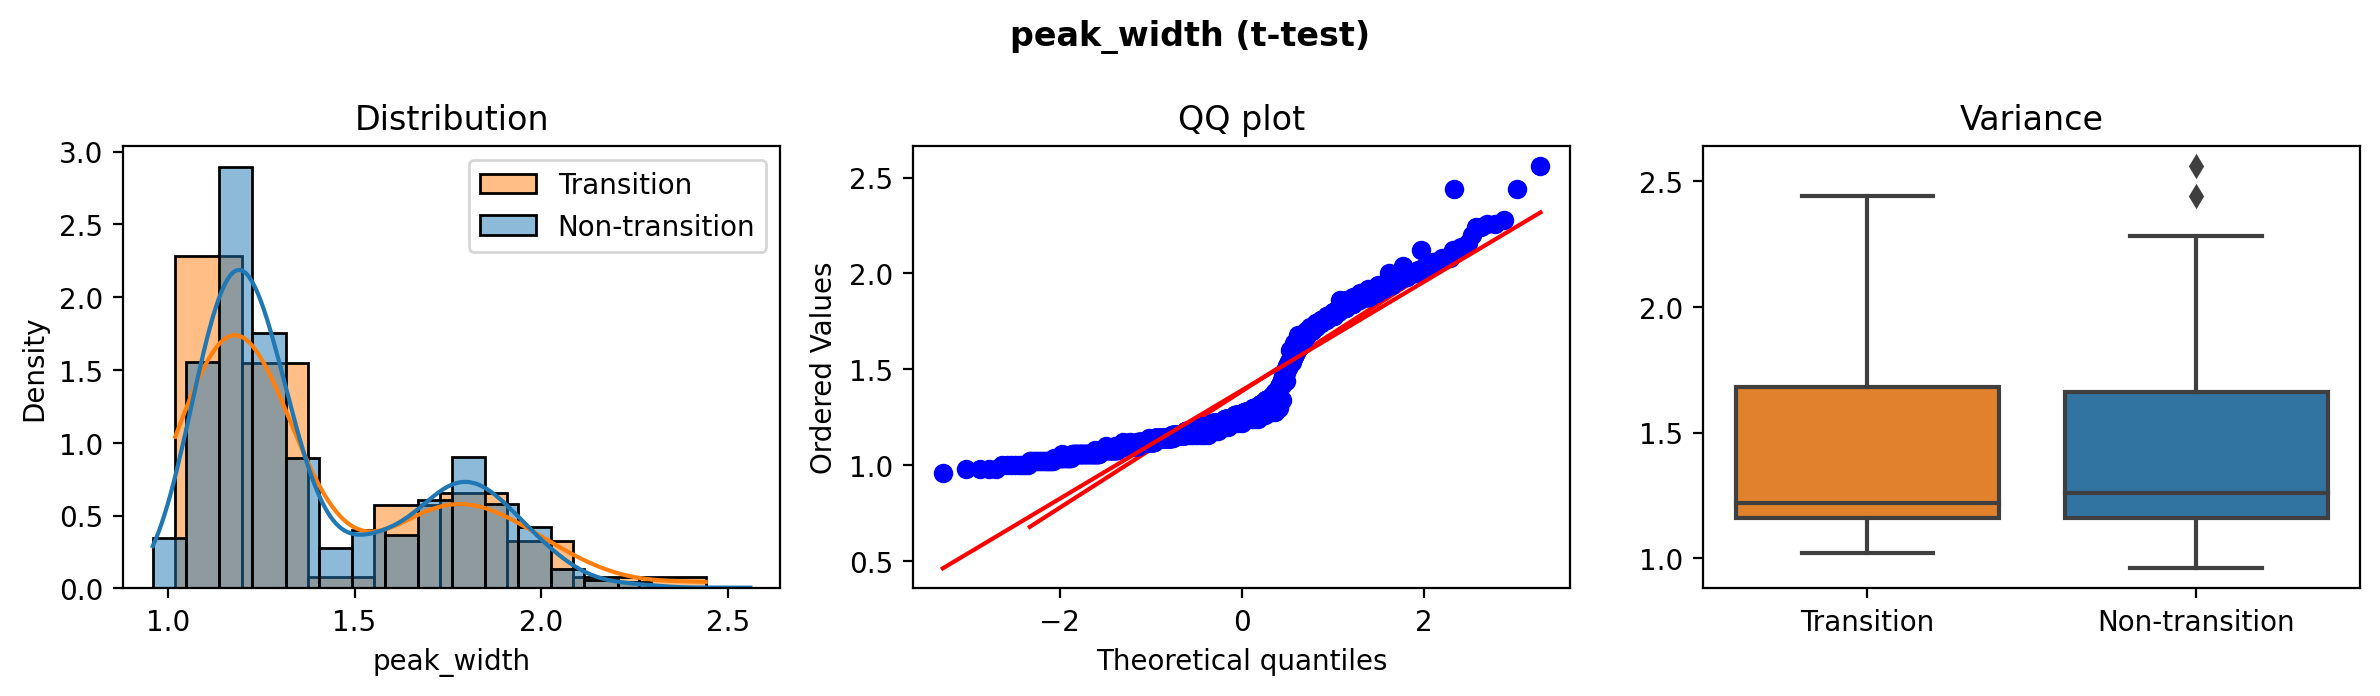

peak_sharpness      : t-test        (p=0.576)  | normal_a=True, normal_b=True, equal_var=True → normal or large n → t-test used


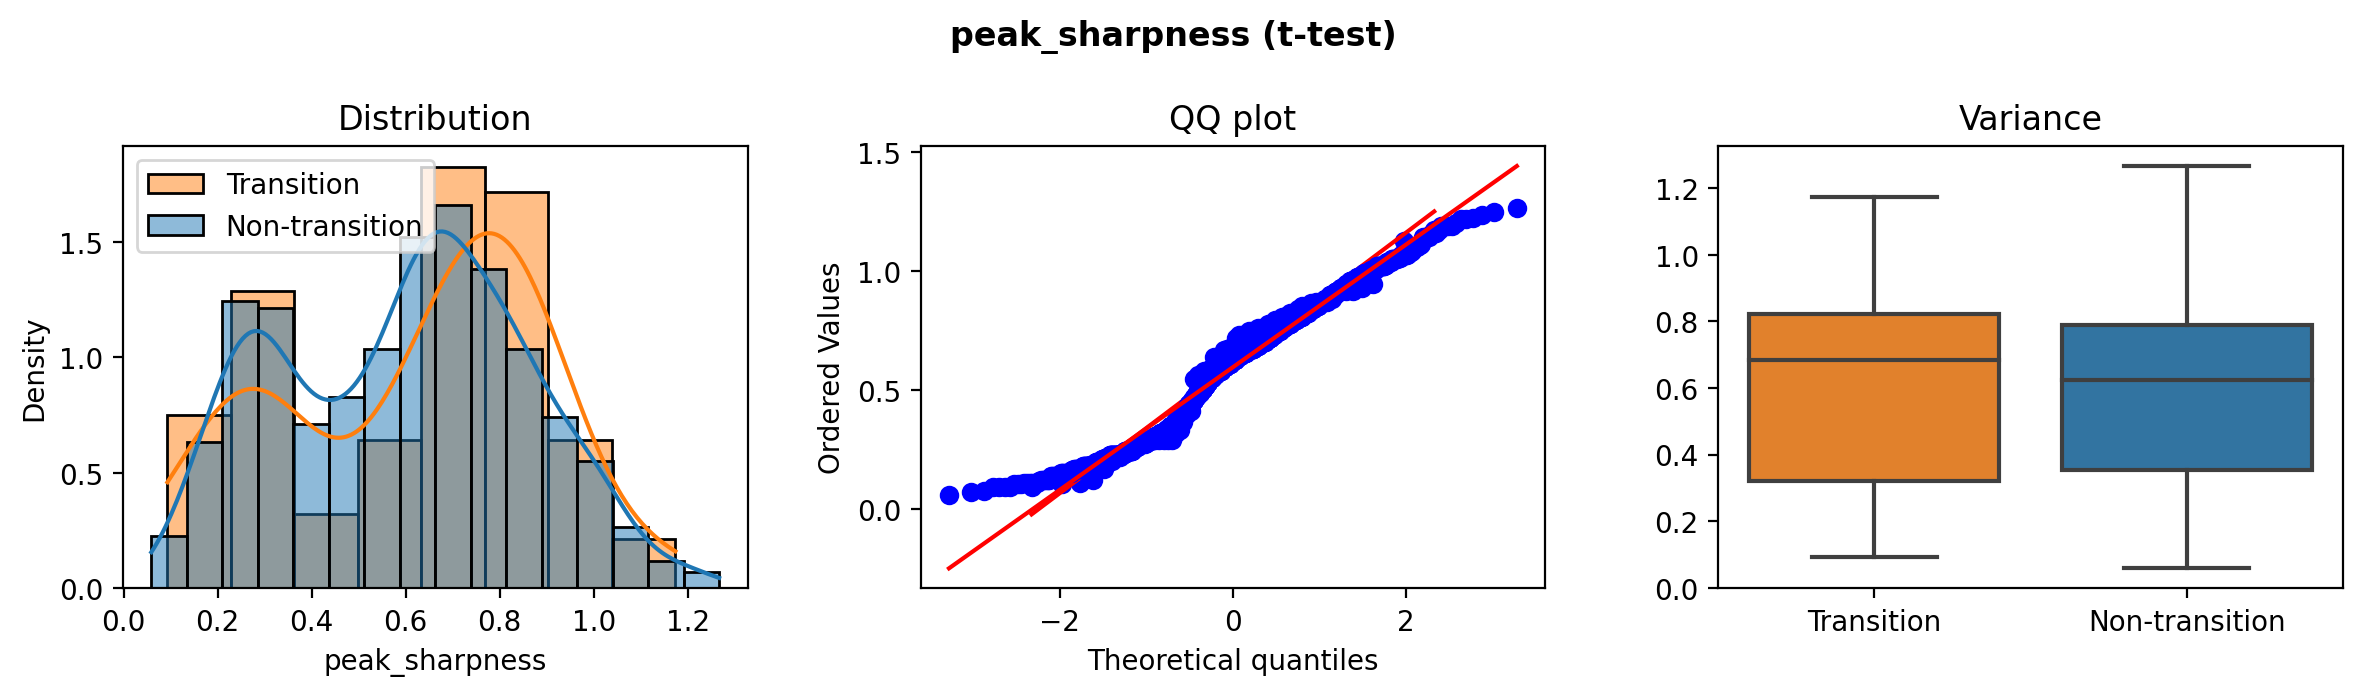

inflection_amp      : t-test        (p=0.3)  | normal_a=True, normal_b=True, equal_var=True → normal or large n → t-test used


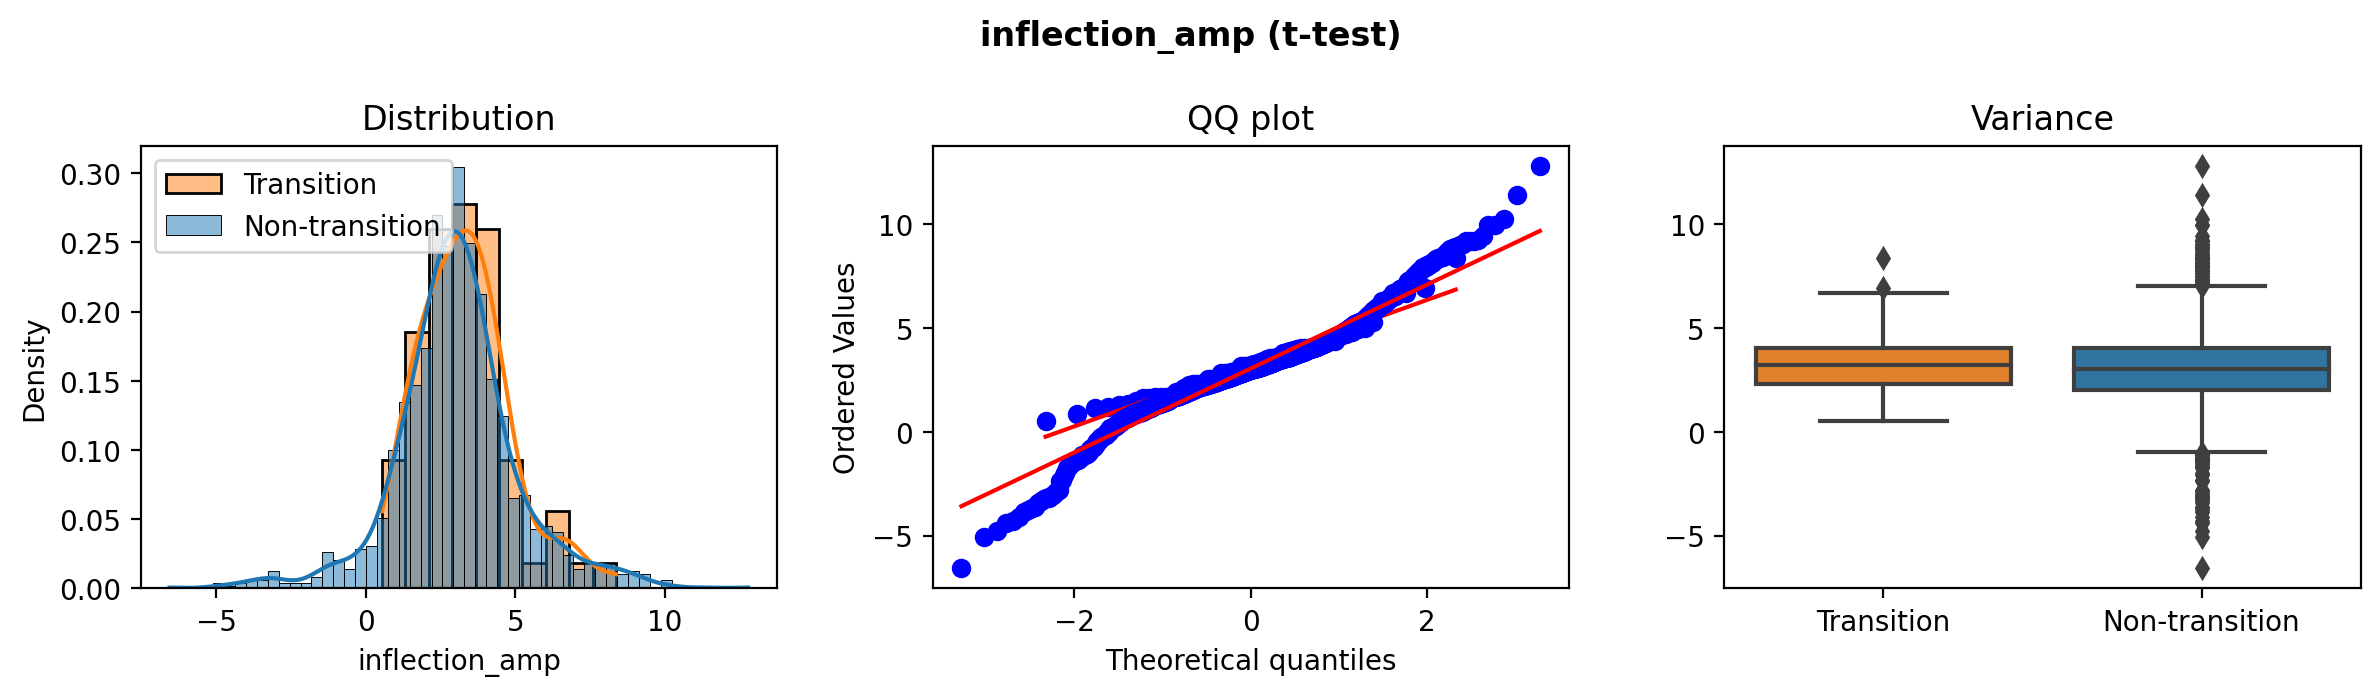

exp_lambda          : t-test        (p=0.692)  | normal_a=True, normal_b=True, equal_var=True → normal or large n → t-test used


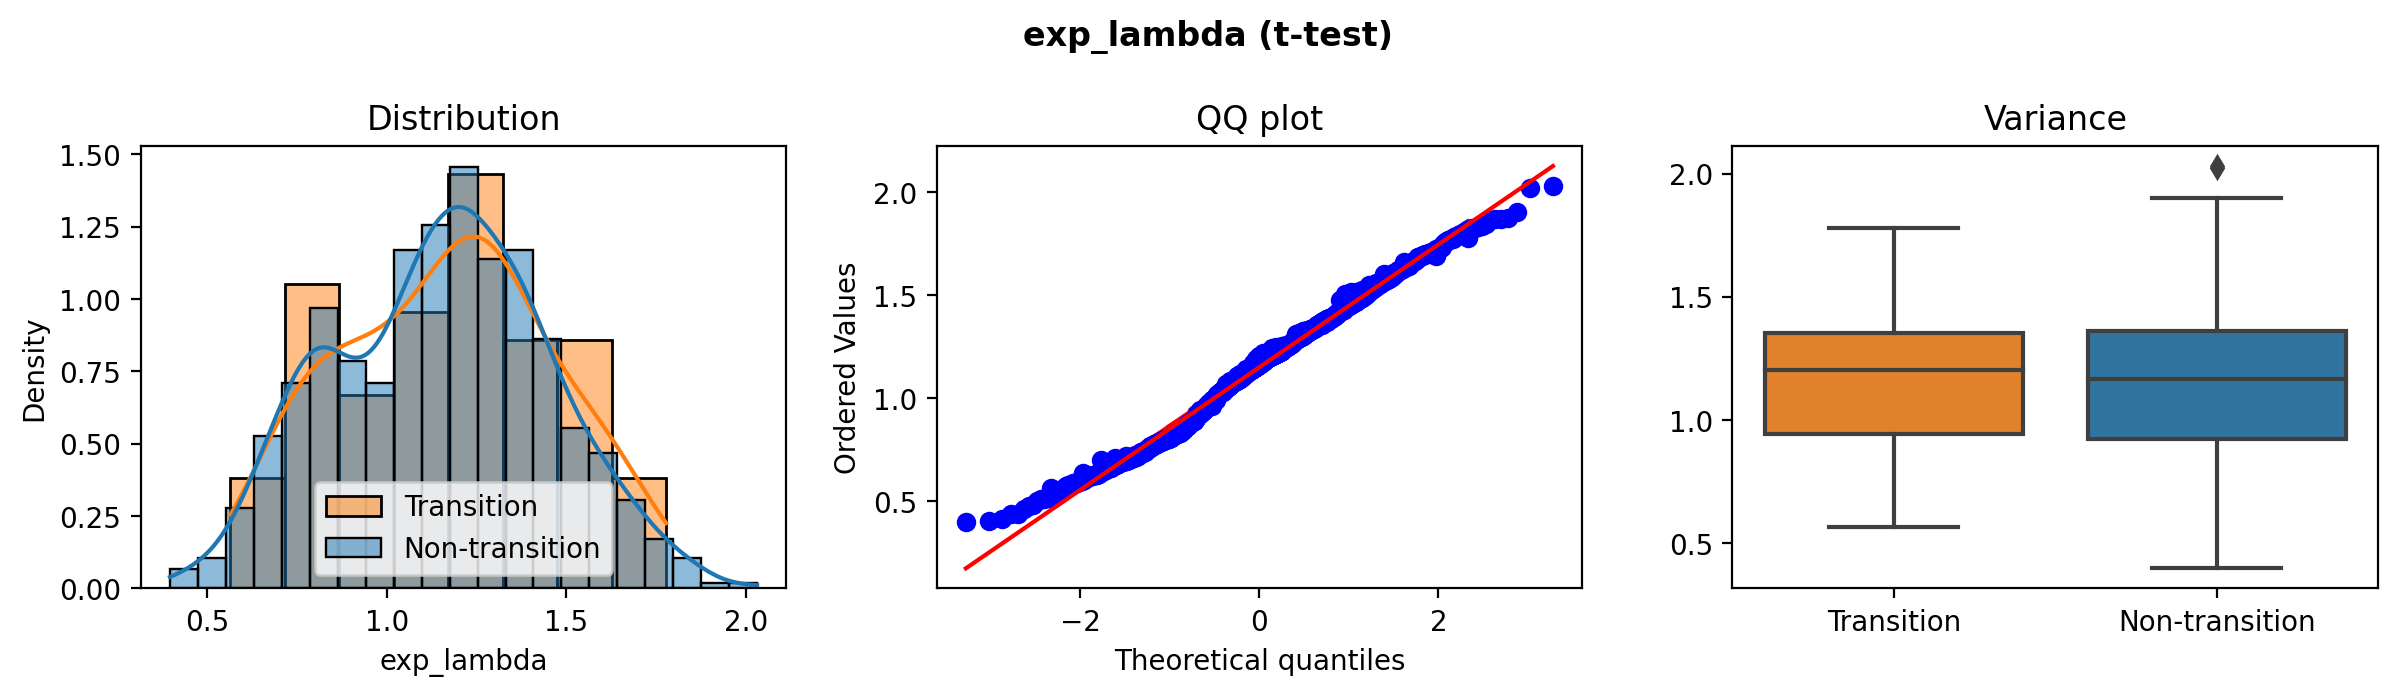

In [21]:

features = ["ramp_amp", "peak_width", "peak_sharpness", "inflection_amp", "exp_lambda"]

res = compare_transition_features(df_marked, features)



### STEP 4: Analyze LFP around transition points

#### Get LFP windows 

In [95]:
#get LFP windows around/before/after transition points 

# 1) Build the ISI-to-next-spike table for transitions
isi_tab = transition_next_isi_windows(
    df_marked,
    time_col="spk_times_ms",
    onset_col="is_long_to_short_isi_onset"
)

# 2) Onset times (s) for events that actually have a next spike
onsets_s    = isi_tab.loc[isi_tab["has_next"], "onset_time_s"].to_numpy(float)
post_each_s = isi_tab.loc[isi_tab["has_next"], "next_isi_s"].to_numpy(float)

# 3) Fixed post window = global minimum next_isi (with a reasonable floor)
post_fixed_s = fixed_post_window_from_min_isi(isi_tab, min_floor_s=0.050)  # e.g., ≥50 ms

#    Make pre symmetric, as you wanted:
pre_s    = post_fixed_s
around_s = post_fixed_s  # (keep if you’ll use it elsewhere)

print(f"Fixed post window: {post_fixed_s:.3f} s (and pre set to the same)")

# 4A) Variable post windows = next_isi per event (padded to max)
epochs_var, t_rel_var, used_post_s = extract_epochs_variable_post(
    lfp=lfp_filt, fs=lfp_fs,
    onsets_s=onsets_s,
    next_post_s_each=post_each_s,
    pre_s=pre_s
)

# 4B) Fixed, symmetric windows for all events
epochs_fix, t_rel_fix = extract_epochs_fixed_post(
    lfp=lfp_filt, fs=lfp_fs,
    onsets_s=onsets_s,
    pre_s=pre_s,
    post_s_fixed=post_fixed_s
)

print(f"Variable post windows: median={np.nanmedian(used_post_s):.3f}s, min={np.nanmin(used_post_s):.3f}s")
print("epochs_var:", epochs_var.shape, "| epochs_fix:", epochs_fix.shape)

Fixed post window: 0.318 s (and pre set to the same)
Variable post windows: median=1.160s, min=0.318s
epochs_var: (69, 14792) | epochs_fix: (69, 1591)


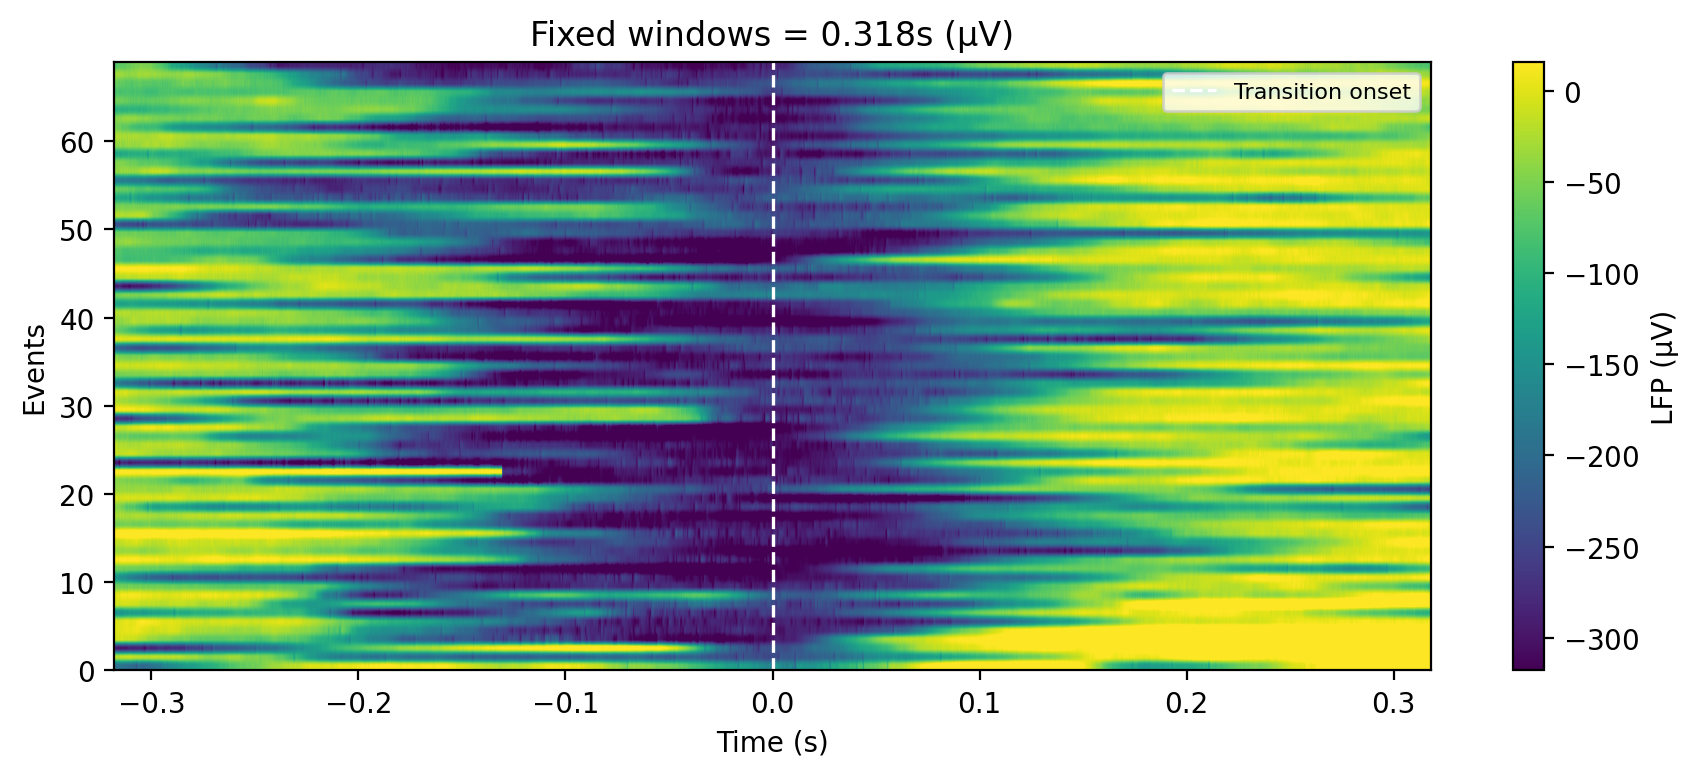

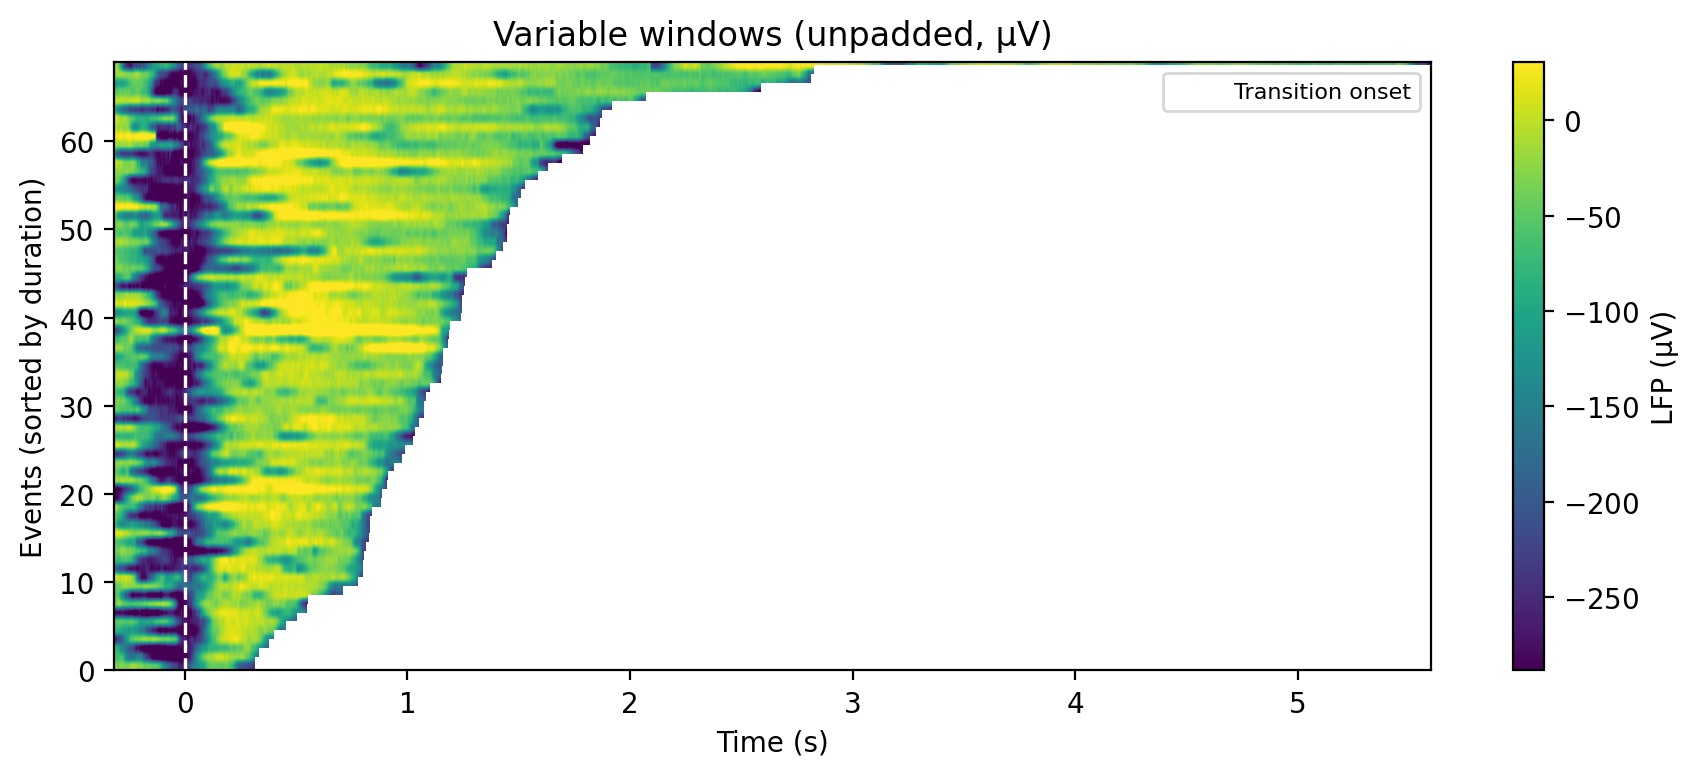

In [96]:
# 5) Visualizations 
plot_lfp_epoch_heatmap(
    epochs_fix, t_rel_fix,
    title=f"Fixed windows = {post_fixed_s:.3f}s (µV)"
)

plot_lfp_epoch_heatmap(
    ep_each, t_each,
    title="Variable windows (unpadded, µV)"
)



#### Control plots - also plot heatmaps for random non transition spikes
We are seeing a drop in LFP voltage before spikes for ALL spikes 

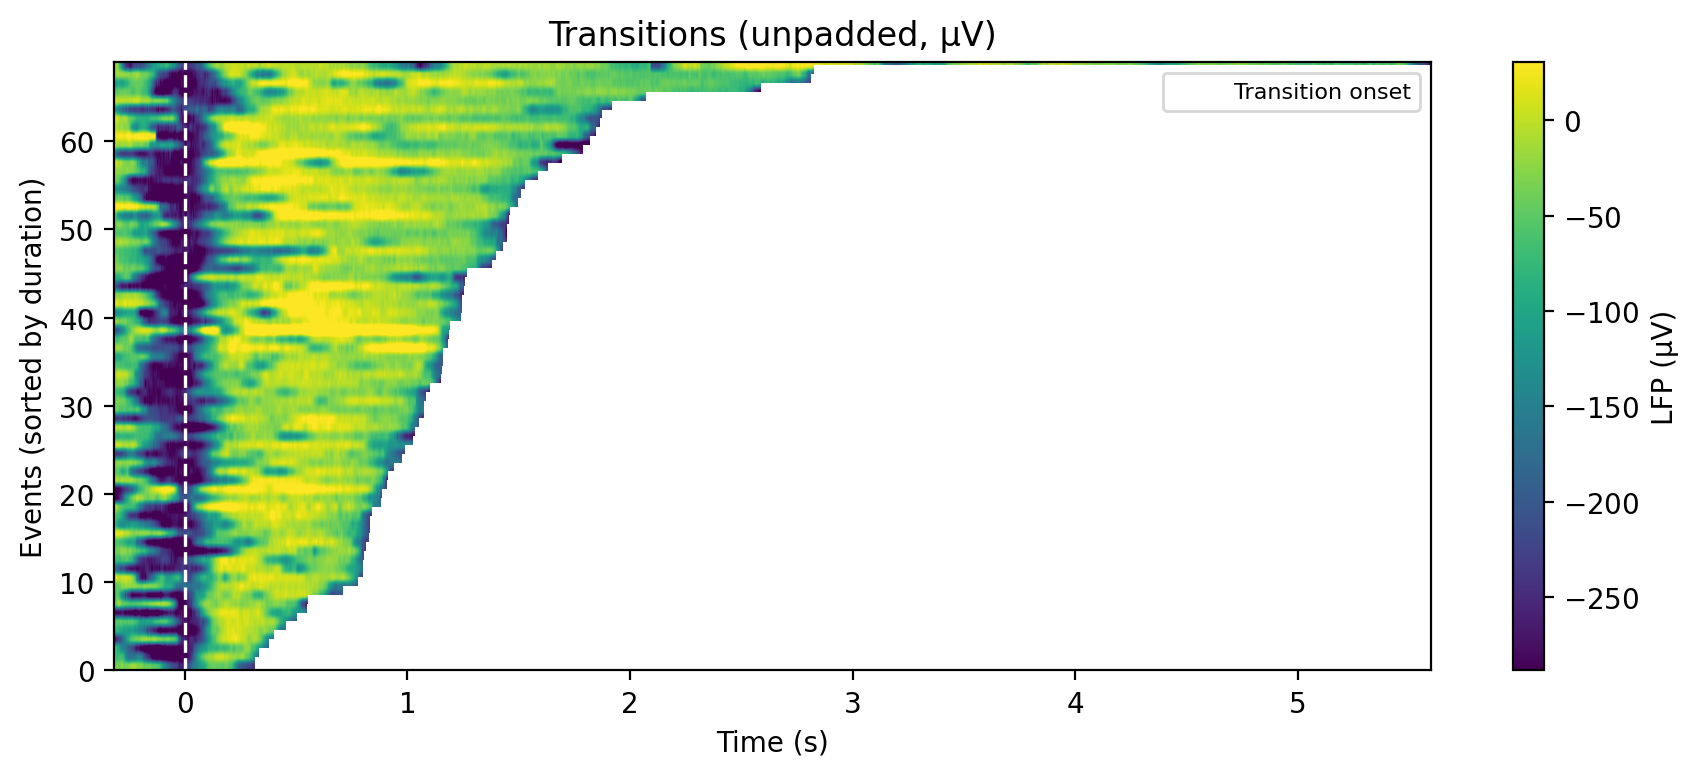

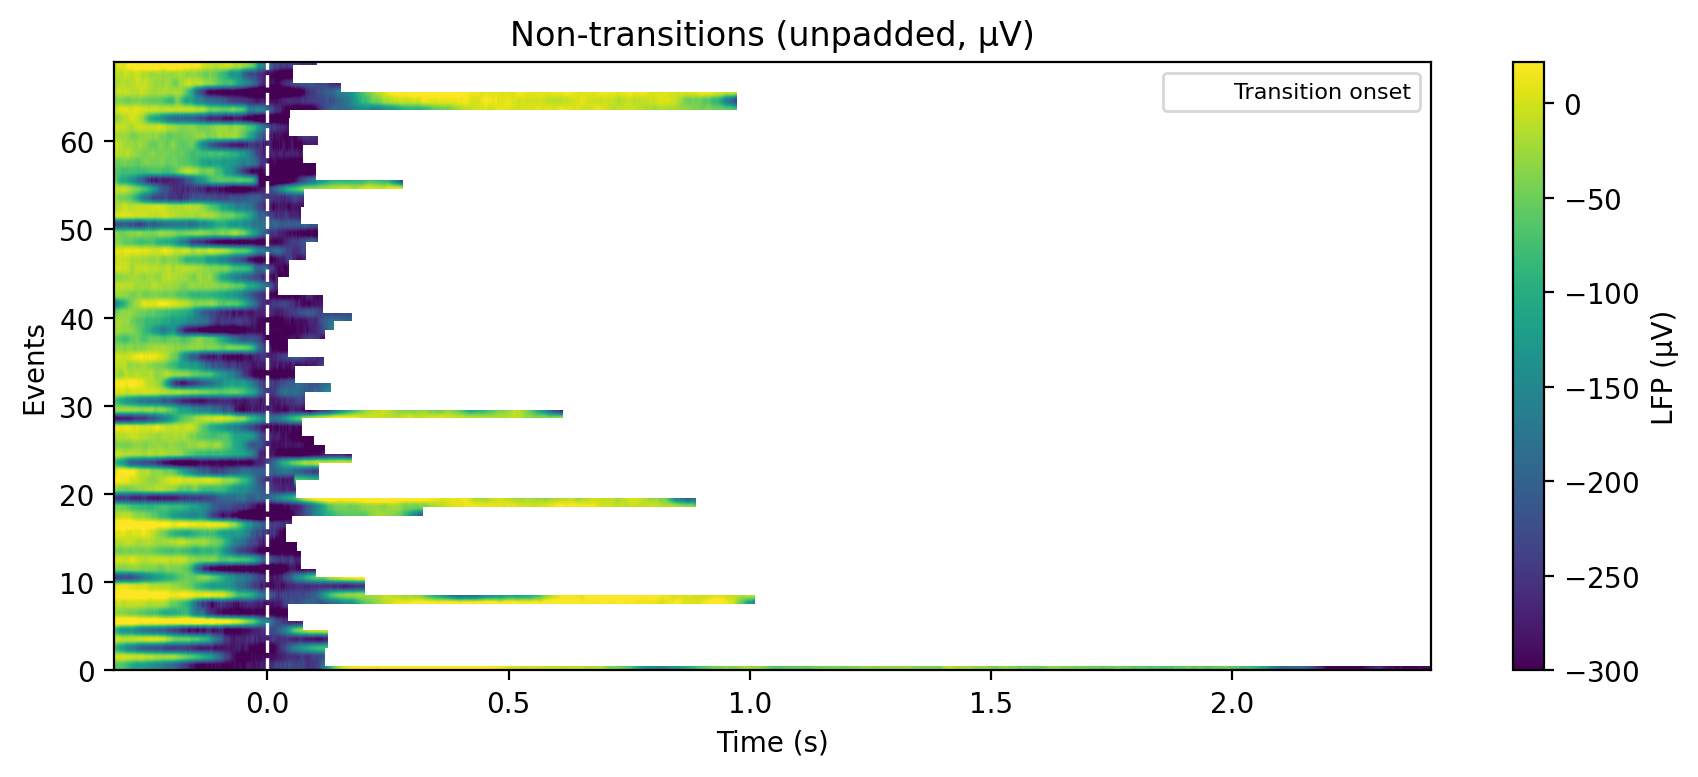

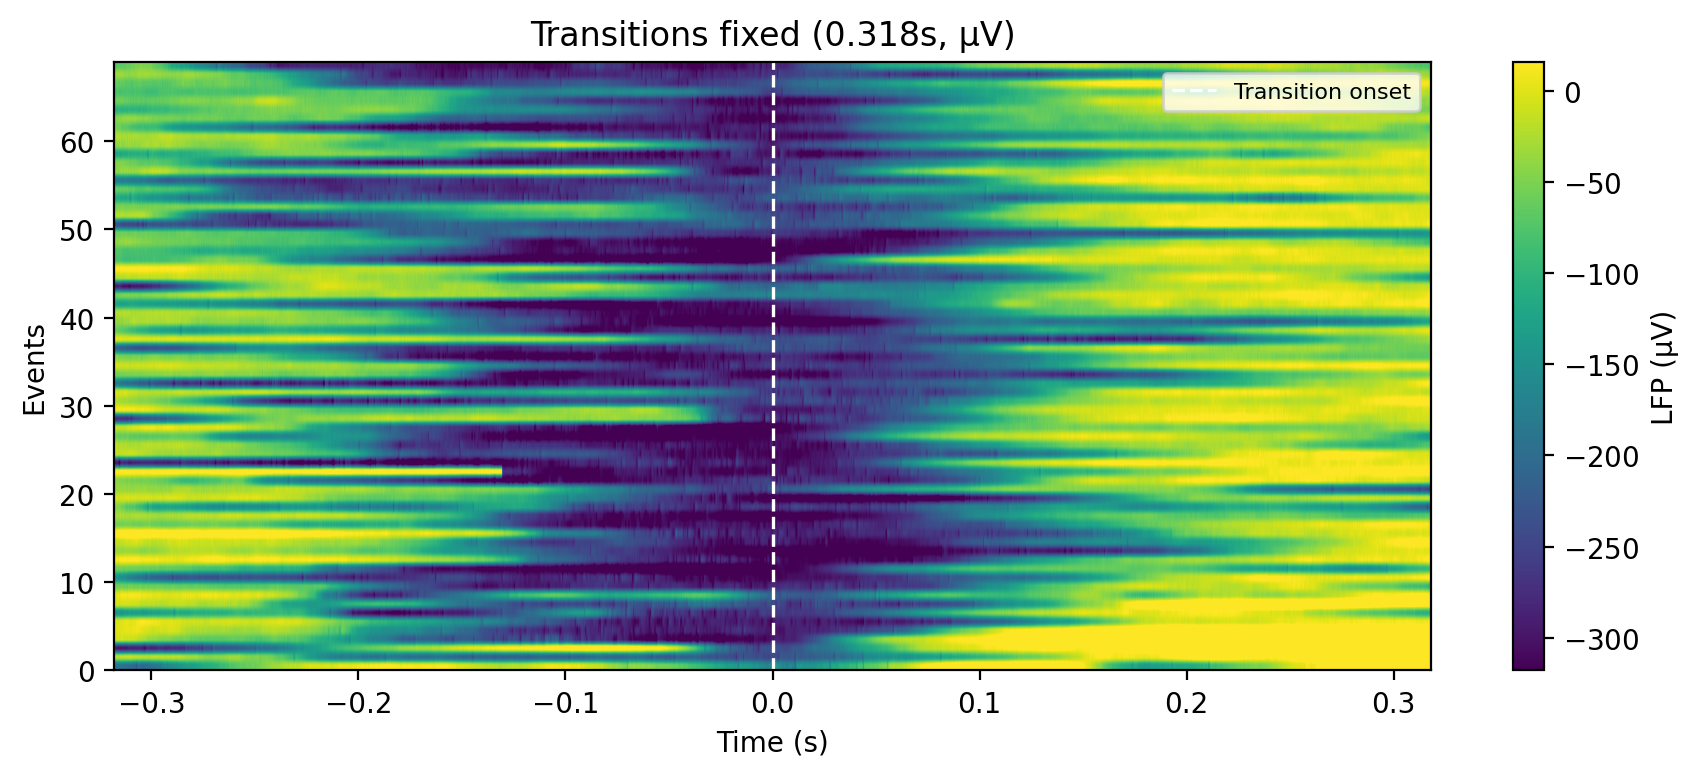

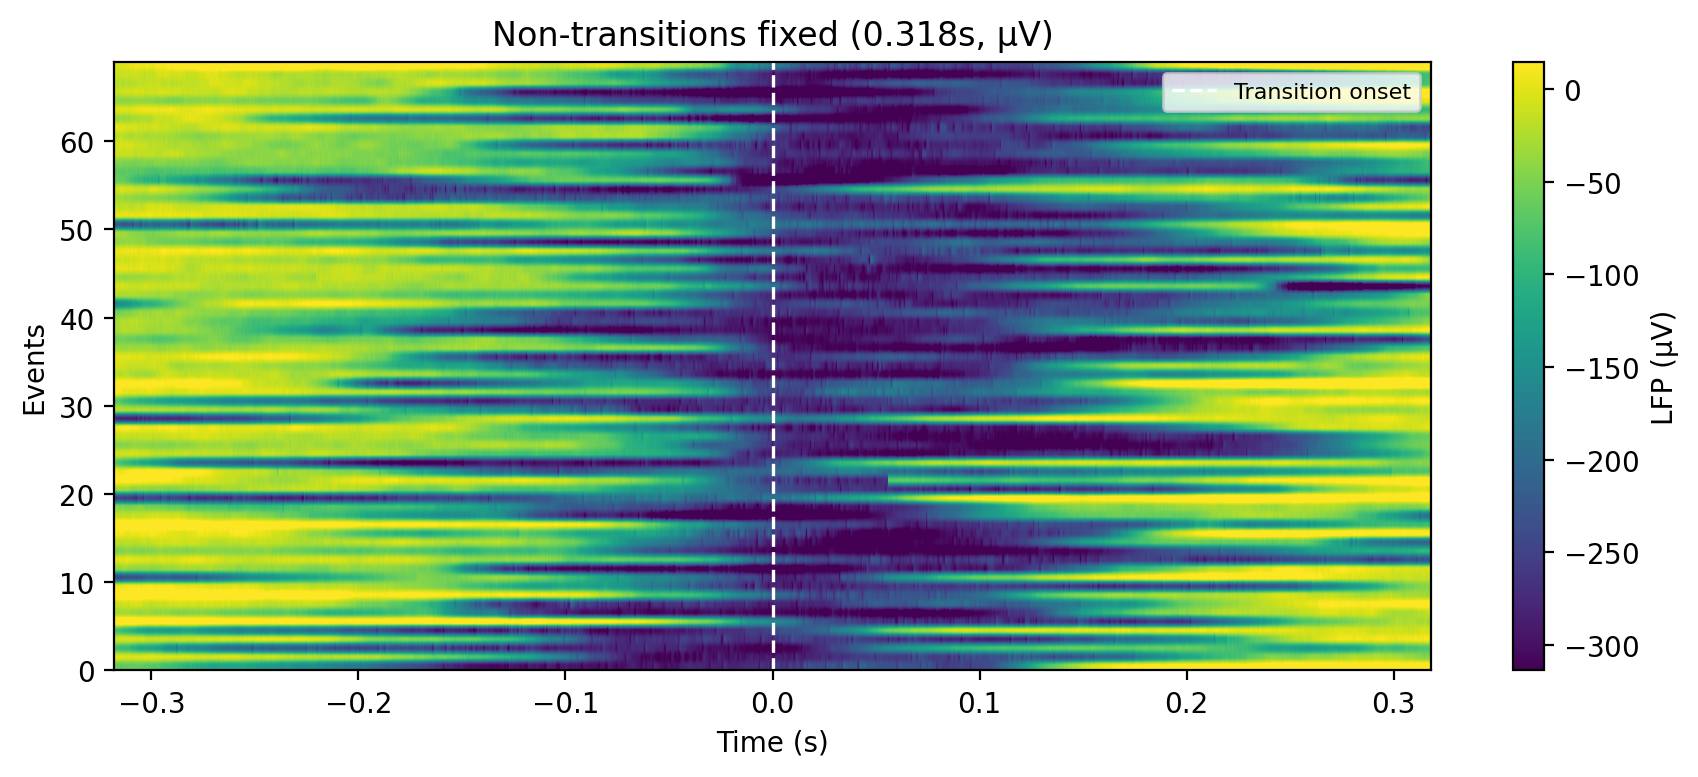

In [99]:
# --- Pick non-transition spikes (same count as transitions)
non_idx = np.where(~df_marked["is_long_to_short_isi_onset"])[0]
rng = np.random.default_rng(1)
non_idx = rng.choice(non_idx, size=len(onsets_s), replace=False)

# --- Get their times and ISIs
t_ms = df_marked["spk_times_ms"].to_numpy(float)
non_onsets_s = t_ms[non_idx] / 1000
non_next_s = t_ms[non_idx + 1] / 1000
non_post_s = non_next_s - non_onsets_s

# --- Extract epochs
epochs_var_non, t_var_non, used_post_non = extract_epochs_variable_post(
    lfp_filt, lfp_fs, non_onsets_s, non_post_s, pre_s
)
epochs_fix_non, t_fix_non = extract_epochs_fixed_post(
    lfp_filt, lfp_fs, non_onsets_s, pre_s, post_fixed_s
)

# --- Plot
plot_lfp_epoch_heatmap(ep_each, t_each, title="Transitions (unpadded, µV)")
plot_lfp_epoch_heatmap(epochs_var_non, t_var_non, title="Non-transitions (unpadded, µV)")

plot_lfp_epoch_heatmap(epochs_fix, t_rel_fix, title=f"Transitions fixed ({post_fixed_s:.3f}s, µV)")
plot_lfp_epoch_heatmap(epochs_fix_non, t_fix_non, title=f"Non-transitions fixed ({post_fixed_s:.3f}s, µV)")


#### Analyze LFP windows using specparam

In [100]:
#compute power spectra using multitaper and run specparam to extract aperiodic offset, exponent, and also periodic params 


In [108]:
from specparam import SpectralTimeModel
import numpy as np
import pandas as pd
from tqdm import tqdm

def specparam_timecourse_per_epoch(
    epochs: np.ndarray,
    fs: float,
    freq_range=(1, 90),
    window_length_sec=0.25,
    decim_factor=10,
    time_bandwidth=2.0,
    progress=True,
) -> pd.DataFrame:
    """
    Compute time-resolved Specparam fits within each LFP epoch.

    Each epoch is subdivided into short sliding windows (e.g., 250 ms),
    each window's spectrum is parameterized (aperiodic + peaks),
    and parameters are concatenated across time.

    Returns a tidy DataFrame with one row per sub-window per epoch.
    """
    results = []
    iterator = tqdm(range(len(epochs)), desc="SpectralTimeModel per epoch") if progress else range(len(epochs))

    for eid in iterator:
        sig = epochs[eid]
        if not np.isfinite(sig).any():
            continue

        # multitaper spectrogram + Specparam over time
        model, freqs, win_times = compute_lfp_windows(
            lfp_signal=sig,
            fs=fs,
            method="multitaper",
            window_length_sec=window_length_sec,
            freq_range=freq_range,
            time_bandwidth=time_bandwidth,
            decim_factor=decim_factor,
            progress=False,
            n_jobs=1,
        )

        aperiodic = model.get_params('aperiodic_params')   # shape: (n_bins, 2) -> [offset, exponent]
        peak_params = model.get_params('peak_params')      # list-like per bin; may be empty/var-shaped

        for (ap, peaks, (samp_lo, samp_hi)) in zip(aperiodic, peak_params, win_times):
            t_mid_s = ((samp_lo + samp_hi) / 2) / fs
            off, exp = ap

            # ---- Robust peak handling across Specparam variants ----
            n_peaks = 0
            peak_cf = peak_amp = peak_bw = np.nan

            if peaks is not None:
                # ensure 2D: (n_peaks, >=3). Handle scalar/1D/2D/excess columns.
                p2d = np.atleast_2d(peaks).astype(float)  # (n_peaks, n_cols)
                # Remove any rows that are all-nan or empty
                valid_rows = ~np.all(~np.isfinite(p2d), axis=1)
                p2d = p2d[valid_rows]
                if p2d.size and p2d.shape[1] >= 3:
                    n_peaks = p2d.shape[0]
                    # choose dominant peak = max amplitude in column 1
                    try:
                        idx = int(np.nanargmax(p2d[:, 1]))
                        cf, amp, bw = p2d[idx, :3]
                        peak_cf, peak_amp, peak_bw = cf, amp, bw
                    except ValueError:
                        # all-NaN amplitudes
                        n_peaks = 0
                        peak_cf = peak_amp = peak_bw = np.nan

            results.append({
                "epoch_id": eid,
                "time_rel_s": t_mid_s,
                "aperiodic_offset": off,
                "aperiodic_exp": exp,
                "n_peaks": int(n_peaks),
                "peak_cf": peak_cf,
                "peak_amp": peak_amp,
                "peak_bw": peak_bw,
            })

    return pd.DataFrame(results)


   

In [109]:
# run on your fixed transition LFP epochs
specparam_tc = specparam_timecourse_per_epoch(
    epochs=epochs_fix,
    fs=lfp_fs,
    freq_range=(1, 90),
    window_length_sec=0.250,  # 250-ms bins inside the window
    decim_factor=5,
    time_bandwidth=2.0,
)


SpectralTimeModel per epoch:   0%|                                                                                                       | 0/69 [00:00<?, ?it/s]

Fitting model across 319 power spectra.


SpectralTimeModel per epoch:   1%|█▍                                                                                             | 1/69 [00:02<03:15,  2.88s/it]

Fitting model across 319 power spectra.


SpectralTimeModel per epoch:   3%|██▊                                                                                            | 2/69 [00:05<03:13,  2.89s/it]

...

SpectralTimeModel per epoch:  97%|███████████████████████████████████████████████████████████████████████████████████████████▎  | 67/69 [03:16<00:05,  2.98s/it]

Fitting model across 319 power spectra.


SpectralTimeModel per epoch:  99%|████████████████████████████████████████████████████████████████████████████████████████████▋ | 68/69 [03:19<00:03,  3.05s/it]

Fitting model across 319 power spectra.


SpectralTimeModel per epoch: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 69/69 [03:22<00:00,  2.93s/it]


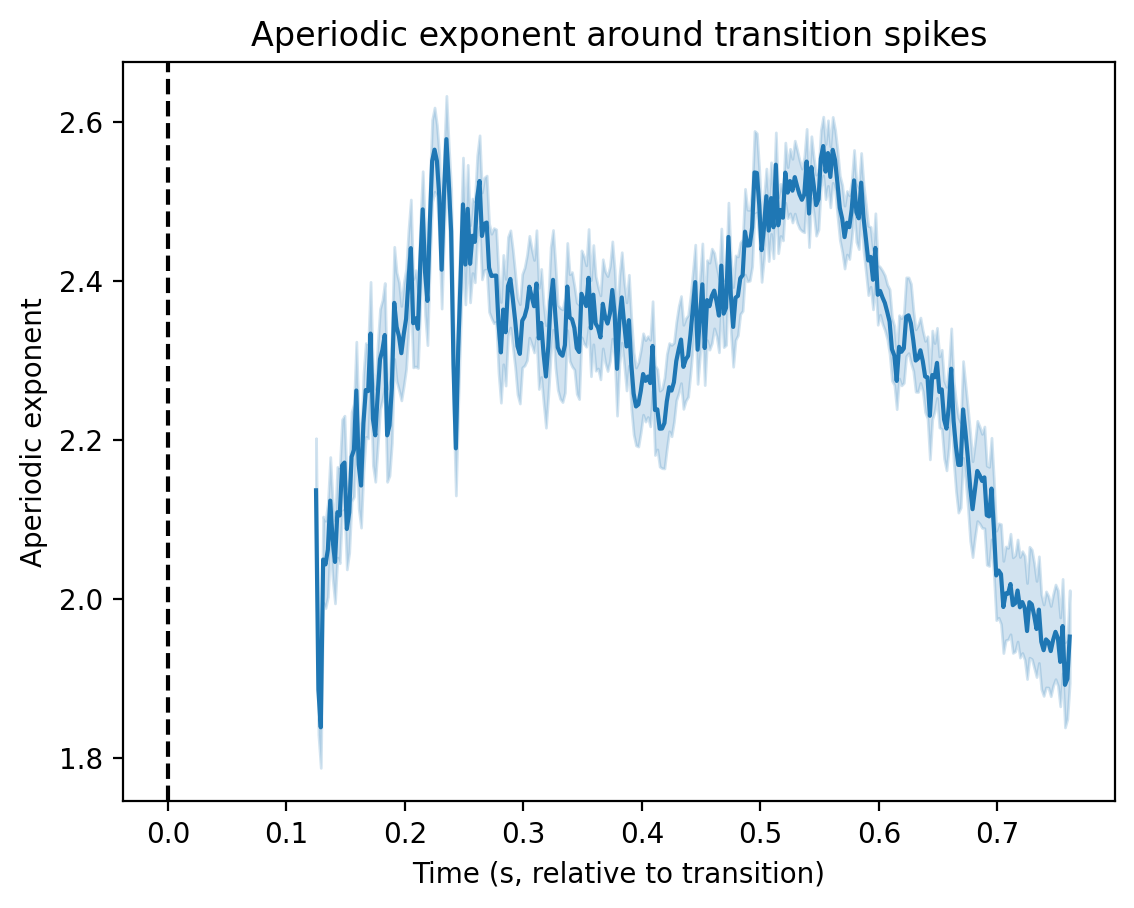

In [110]:


sns.lineplot(
    data=specparam_tc,
    x="time_rel_s", y="aperiodic_exp",
    estimator="mean", errorbar="se",
)
plt.axvline(0, color="k", ls="--")
plt.title("Aperiodic exponent around transition spikes")
plt.xlabel("Time (s, relative to transition)")
plt.ylabel("Aperiodic exponent")
plt.show()
